# Prediksi Permintaan Sepeda Sewa per Jam (Bike Sharing Demand Forecasting)

Notebook ini membangun model regresi untuk memprediksi jumlah penyewaan sepeda per jam (`cnt`), sebagai dasar keputusan operasional tim **Operations / Fleet Management** pada perusahaan bike-sharing.

Alur pembahasan: Business Understanding, Data Understanding, Data Cleaning, Exploratory Data Analysis, Feature Engineering, Modeling, Evaluation, Explainability, Business Impact, dan Conclusion.


## 1. Business Understanding

### 1.1 Stakeholder
Tim **Operations / Fleet Management** pada perusahaan bike-sharing. Tim ini bertanggung jawab
untuk mendistribusikan ulang (*rebalancing*) armada sepeda antar stasiun serta mengatur jumlah
staf operasional di setiap jam operasional.

### 1.2 Problem Statement
Saat ini tim operasional **tidak memiliki cara untuk mengantisipasi permintaan (demand) penyewaan
sepeda per jam**. Akibatnya muncul dua jenis kerugian:
- **Kekurangan sepeda (shortage) saat jam permintaan tinggi**: calon penyewa tidak terlayani,
  sehingga perusahaan kehilangan potensi pendapatan (*lost rides/revenue*).
- **Kelebihan sepeda (oversupply) saat jam permintaan rendah**: sepeda menganggur di stasiun yang
  salah, sehingga biaya rebalancing/distribusi terbuang sia-sia.

### 1.3 Goal
Membangun model regresi yang dapat **memprediksi jumlah total penyewaan sepeda per jam (`cnt`)**
dengan tingkat error yang cukup rendah untuk mendukung keputusan **rebalancing armada dan
penjadwalan staf secara proaktif**, bukan reaktif seperti kondisi saat ini.

Satu model prediksi demand per jam ini bisa diterjemahkan menjadi beberapa rekomendasi operasional
sekaligus: jadwal rebalancing armada, kebutuhan staf per jam/musim, dan perencanaan kontingensi
cuaca, semuanya dari satu output prediksi yang sama.

### 1.4 Analytical Approach
Ini adalah masalah **regresi** karena target (`cnt`) adalah variabel numerik kontinu (jumlah
penyewaan). Rencana kerjanya:
1. Pemahaman data: struktur, kualitas, dan pola dasar (Data Understanding, Data Cleaning,
   EDA).
2. Bangun baseline data (rata-rata keseluruhan, rata-rata per jam) sebagai titik pembanding, supaya
   nanti bisa dinilai objektif apakah model yang dibangun benar-benar berguna.
3. Mencoba membuat model regresi linear (OLS) dulu sebagai baseline yang mudah diinterpretasikan.
4. Baru kemudian coba model yang lebih kompleks (Ridge, Decision Tree, Random Forest, XGBoost)
   untuk melihat apakah pola non-linear dalam data bisa ditangkap lebih baik.
5. Tuning hyperparameter, lalu analisis residual untuk memahami kondisi di mana model dapat/tidak
   dapat dipercaya.


### 1.5 Evaluation Metrics

**Metrik utama: RMSE (Root Mean Squared Error)**

Dari sisi bisnis, kesalahan prediksi pada jam permintaan puncak (kehabisan sepeda di jam sibuk)
jauh lebih mahal konsekuensinya dibanding kesalahan kecil pada jam sepi. RMSE menghukum error besar
lebih berat daripada error kecil, selaras dengan karakter biaya bisnis tersebut.

**Kandidat metrik pendukung**:
- **MAE (Mean Absolute Error)**
- **MAPE (Mean Absolute Percentage Error)**
- **RMSLE (Root Mean Squared Log Error)**
- **R²**

**Definisi model "Good Enough".** Standar keberhasilan model ditentukan lewat
proses: seberapa jauh model mengalahkan baseline, seberapa kecil gap antara skor train vs
test, dan di titik mana peningkatan performa mulai mengalami *diminishing
returns*, bukan angka yang ditetapkan di awal sebelum melihat data.


## 2. Data Understanding

Dataset yang digunakan adalah `data_bike_sharing.csv`, berisi data historis penyewaan sepeda per
jam. Bagian ini merangkum jumlah baris dan kolom, tipe data tiap kolom, serta arti masing-masing
kolom secara bisnis.

### Data Dictionary

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `dteday` | string (tanggal) | Tanggal observasi (format YYYY-MM-DD). Masih berupa string sehingga belum bisa langsung dipakai sebagai fitur numerik, perlu diolah lebih lanjut di bagian Feature Engineering. |
| `hr` | int (0-23) | Jam dalam sehari saat observasi dicatat. |
| `season` | int (1-4) | Musim: 1 = winter, 2 = spring, 3 = summer, 4 = fall. Kategorikal nominal. |
| `holiday` | int (0/1) | Apakah hari tersebut hari libur (1) atau bukan (0). Sudah biner. |
| `weathersit` | int (1-4) | Kondisi cuaca, dari 1 (cerah) hingga 4 (cuaca buruk/ekstrem), bersifat ordinal (semakin besar, semakin buruk). |
| `temp` | float (0-1) | Suhu yang sudah dinormalisasi ke rentang 0-1. |
| `atemp` | float (0-1) | Suhu "terasa" (feels-like), sudah dinormalisasi ke rentang 0-1. |
| `hum` | float (0-1) | Kelembapan (humidity), sudah dinormalisasi ke rentang 0-1. |
| `casual` | int | Jumlah penyewa non-terdaftar (casual). |
| `registered` | int | Jumlah penyewa terdaftar (member). |
| `cnt` | int | **Target prediksi.** Total penyewaan sepeda per jam. |



In [1]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/data_bike_sharing.csv')
df.shape

(12165, 11)

In [2]:
df.head()

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      12165 non-null  str    
 1   hum         12165 non-null  float64
 2   weathersit  12165 non-null  int64  
 3   holiday     12165 non-null  int64  
 4   season      12165 non-null  int64  
 5   atemp       12165 non-null  float64
 6   temp        12165 non-null  float64
 7   hr          12165 non-null  int64  
 8   casual      12165 non-null  int64  
 9   registered  12165 non-null  int64  
 10  cnt         12165 non-null  int64  
dtypes: float64(3), int64(7), str(1)
memory usage: 1.0 MB


Ringkasan statistik deskriptif untuk kolom numerik, dipakai untuk konfirmasi rentang nilai (mis.
`temp`/`atemp`/`hum` benar-benar berada di 0-1, `hr` di 0-23) sebelum masuk ke tahap pembersihan
data.

In [4]:
df.describe()

,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
count,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000
mean,0.625451,1.416934,0.029758,2.488615,0.476996,0.498185,11.519770,35.834443,153.436580,189.271023
std,0.192102,0.635937,0.169925,1.106157,0.171857,0.192492,6.931872,49.489286,151.046123,181.223903
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,0.470000,1.000000,0.000000,2.000000,0.333300,0.340000,6.000000,4.000000,34.000000,40.000000
50%,0.620000,1.000000,0.000000,2.000000,0.484800,0.500000,12.000000,17.000000,115.000000,142.000000
75%,0.780000,2.000000,0.000000,3.000000,0.621200,0.660000,18.000000,49.000000,220.000000,282.000000
max,1.000000,4.000000,1.000000,4.000000,1.000000,1.000000,23.000000,362.000000,876.000000,970.000000


## 3. Simple Data Cleaning

Langkah pembersihan data: cek baris duplikat, cek missing value per kolom (tetap dijalankan
meskipun datanya sekilas sudah terlihat lengkap), lalu menangani kolom yang berisiko menyebabkan *data leakage* pada target.

In [5]:
df.duplicated().sum()

np.int64(0)

Tidak ada baris duplikat. Selanjutnya cek missing value per kolom.

In [6]:
df.isnull().sum()

dteday        0
hum           0
weathersit    0
holiday       0
season        0
atemp         0
temp          0
hr            0
casual        0
registered    0
cnt           0
dtype: int64

Tidak ada missing value pada seluruh kolom (0 di setiap kolom). Dataset ini sudah bersih dari sisi
kelengkapan data, tidak perlu imputasi.

### 3.1 Leakage Check: `casual` + `registered` vs `cnt`

Kolom `casual` dan `registered` masing-masing mencatat jumlah penyewa non-terdaftar dan penyewa
terdaftar per jam. Target `cnt` didefinisikan sebagai total penyewaan per jam. 

In [7]:
leakage_check = (df['cnt'] != df['casual'] + df['registered']).sum()
print(f"Jumlah baris di mana cnt != casual + registered: {leakage_check} dari {len(df)} baris")

Jumlah baris di mana cnt != casual + registered: 0 dari 12165 baris


Terkonfirmasi: pada **100% baris**, `cnt = casual + registered` berlaku secara eksak. Karena itu,
`casual` dan `registered` didrop sebagai prediktor untuk mencegah data leakage, meski tetap
disimpan di dataset untuk konteks eksploratif dan tidak masuk sebagai fitur `X` pada tahap modeling.


In [8]:
df_clean = df.drop(columns=['casual', 'registered'])
df_clean.shape

(12165, 9)

In [9]:
df_clean.head()

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,857


Dataset `df_clean` ini yang jadi basis untuk tahap **Exploratory Data Analysis** dan **Feature
Engineering**.

## 4. Exploratory Data Analysis

Setelah data bersih, langkah berikutnya adalah melihat isinya: bentuk distribusi target, variabel
yang berhubungan dengan permintaan, dan nilai ekstrem yang perlu diperhatikan. Bagian ini juga
menguji dugaan awal soal metrik evaluasi (khususnya MAPE) dari bagian Business Understanding
memakai data sebenarnya.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

### 4.1 Distribusi Target (`cnt`)

Mulai dari pertanyaan paling dasar: bagaimana bentuk distribusi `cnt`? Jawabannya menentukan
apakah dugaan soal metrik evaluasi dari bagian Business Understanding (soal MAPE dan RMSLE) itu
relevan atau tidak.

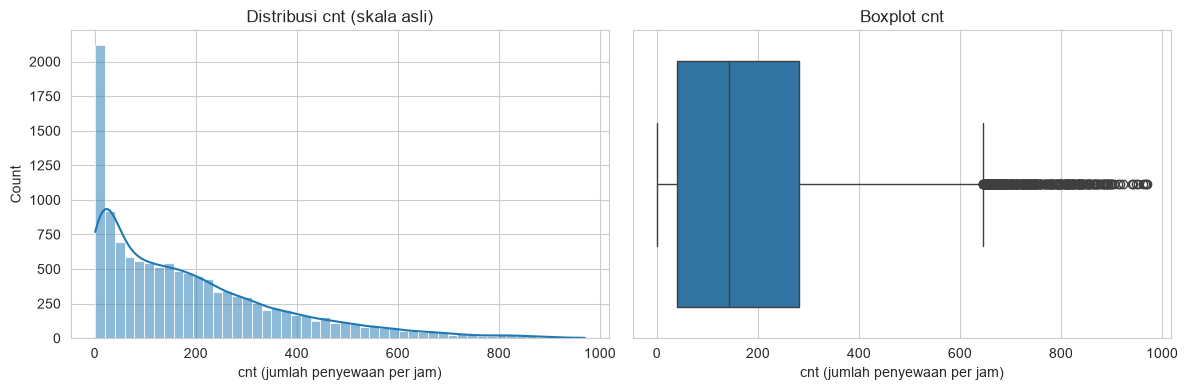

Skewness: 1.27
count    12165.000000
mean       189.271023
std        181.223903
min          1.000000
25%         40.000000
50%        142.000000
75%        282.000000
max        970.000000
Name: cnt, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_clean['cnt'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribusi cnt (skala asli)')
axes[0].set_xlabel('cnt (jumlah penyewaan per jam)')

sns.boxplot(x=df_clean['cnt'], ax=axes[1])
axes[1].set_title('Boxplot cnt')
axes[1].set_xlabel('cnt (jumlah penyewaan per jam)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df_clean['cnt'].skew():.2f}")
print(df_clean['cnt'].describe())

Distribusinya condong ke kanan (*right-skewed*): sebagian besar jam memiliki permintaan rendah
hingga sedang, tapi ada sejumlah jam dengan lonjakan jauh lebih tinggi dari rata-rata (kemungkinan
jam sibuk/*rush hour*), dan nilai minimumnya mendekati nol (`cnt` minimum = 1). Kombinasi banyak
nilai kecil dan distribusi yang miring ini konsisten dengan dugaan bahwa MAPE berpotensi bermasalah
sebagai metrik evaluasi.


In [12]:
naive_pred = df_clean['cnt'].mean()
mape_naive = (np.abs(df_clean['cnt'] - naive_pred) / df_clean['cnt']).mean() * 100

print(f"Prediksi naif (rata-rata cnt): {naive_pred:.1f}")
print(f"MAPE dari prediksi naif ini: {mape_naive:.1f}%")

Prediksi naif (rata-rata cnt): 189.3
MAPE dari prediksi naif ini: 759.4%


Dugaan tersebut terbukti benar: MAPE dari prediksi paling sederhana (menebak rata-rata) sudah
meledak sampai **~759%**, angka yang tidak bisa dipakai untuk mengukur kualitas model secara wajar.
Temuan ini mengonfirmasi keputusan untuk tidak menjadikan MAPE sebagai metrik utama, dan memperkuat
alasan memakai **RMSLE** sebagai metrik diagnostik tambahan di samping RMSE dan MAE.


### 4.2 Hubungan Variabel Numerik dengan Target

Melihat sebaran `temp`, `atemp`, `hum`, dan `hr` terhadap `cnt` untuk melihat variabel mana yang
paling berhubungan dengan tingkat permintaan.

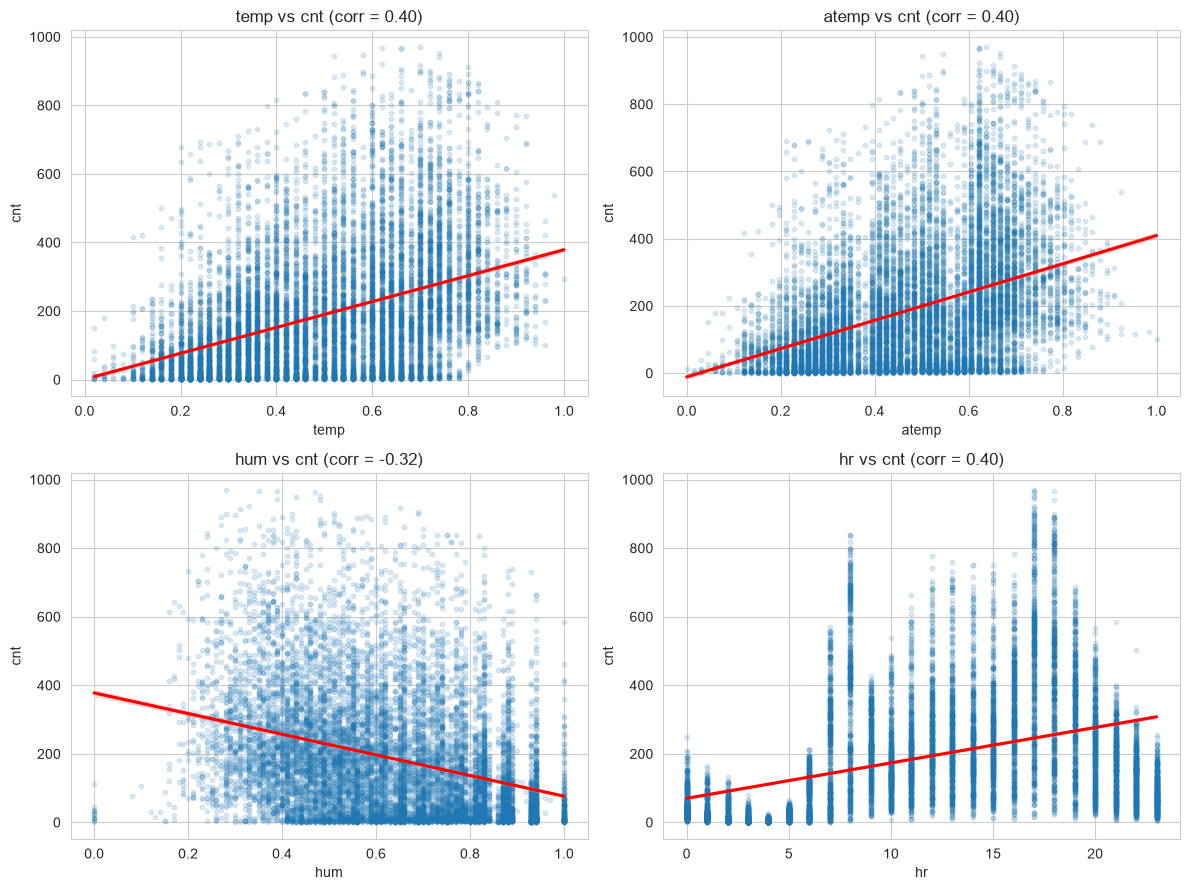

In [13]:
numeric_cols = ['temp', 'atemp', 'hum', 'hr']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.regplot(
        data=df_clean, x=col, y='cnt', ax=ax,
        scatter_kws={'alpha': 0.15, 's': 10}, line_kws={'color': 'red'}
    )
    corr = df_clean[col].corr(df_clean['cnt'])
    ax.set_title(f'{col} vs cnt (corr = {corr:.2f})')

plt.tight_layout()
plt.show()

`hr` (jam dalam sehari) menunjukkan pola jelas namun tidak linear: permintaan naik turun mengikuti
dua puncak, jam berangkat dan pulang kerja/sekolah, sehingga korelasi linear sederhana tidak cukup
menangkap pola ini. Ini alasan `hr` diberi perlakuan khusus (encoding siklis) pada tahap Feature
Engineering. `temp`/`atemp` menunjukkan hubungan positif yang lebih halus dengan `cnt` (permintaan
naik saat suhu nyaman), sementara `hum` cenderung berhubungan negatif (kelembapan tinggi, permintaan
sedikit lebih rendah).


### 4.3 Hubungan Variabel Kategorikal dengan Target

Melihat rata-rata `cnt` pada tiap kategori `season`, `weathersit`, dan `holiday` untuk melihat
apakah kategori-kategori ini membedakan tingkat permintaan secara berarti.

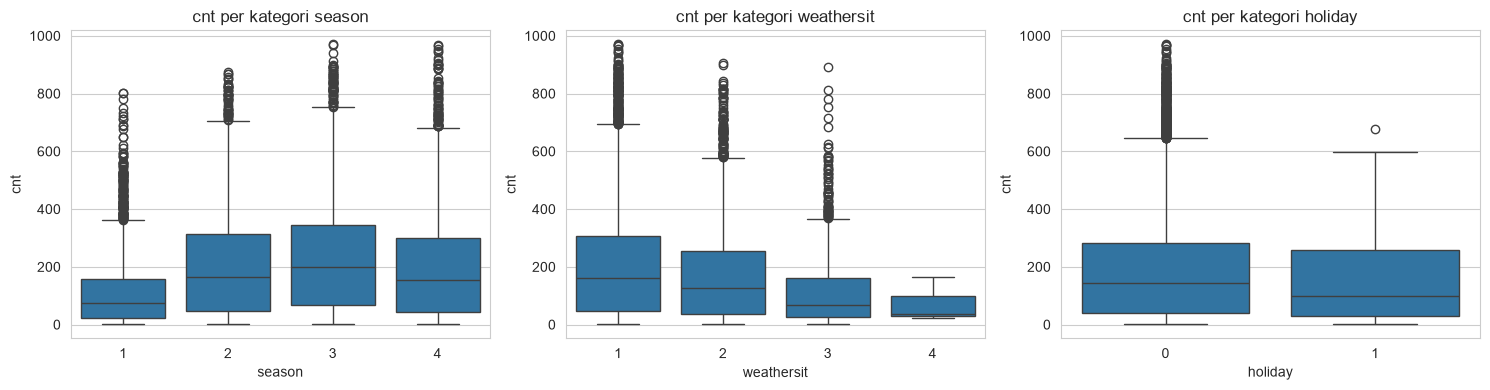

In [14]:
cat_cols = ['season', 'weathersit', 'holiday']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df_clean, x=col, y='cnt', ax=ax)
    ax.set_title(f'cnt per kategori {col}')

plt.tight_layout()
plt.show()

`season` dan `weathersit` sama-sama menunjukkan perbedaan tingkat permintaan yang cukup jelas
antar kategori. Musim dingin (`season=1`) dan cuaca buruk (`weathersit` besar) berasosiasi dengan
permintaan lebih rendah, sesuai intuisi (orang cenderung lebih jarang bersepeda saat dingin/hujan).
`holiday` menunjukkan perbedaan jauh lebih tipis, masuk akal karena jumlah hari libur jauh lebih
sedikit dibanding hari biasa, dan pola permintaan pada hari libur bisa sangat bervariasi tergantung
jenis harinya.

### 4.4 Korelasi Antar Variabel Numerik

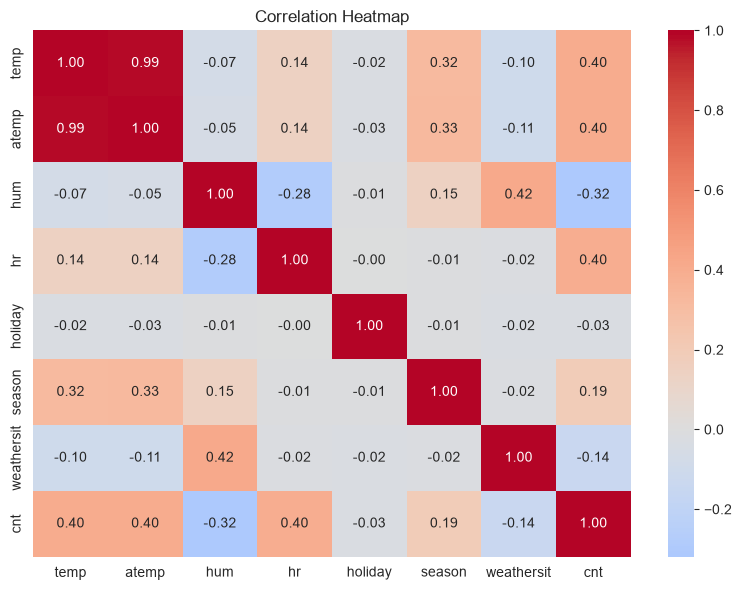

In [15]:
corr_cols = ['temp', 'atemp', 'hum', 'hr', 'holiday', 'season', 'weathersit', 'cnt']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

`temp` dan `atemp` berkorelasi sangat tinggi satu sama lain, keduanya sama-sama mengukur suhu
dengan cara normalisasi berbeda. Kondisi *multicollinearity* ini diperhatikan khususnya saat
menginterpretasikan koefisien model regresi linear pada tahap Modeling, karena bisa membuat
interpretasi masing-masing koefisien kurang stabil.


### 4.5 Pemeriksaan Outlier

Memeriksa nilai ekstrem pada `cnt` menggunakan metode IQR (Interquartile Range), untuk melihat
apakah nilai tinggi tersebut anomali data atau justru sinyal permintaan yang valid (misalnya jam
sibuk yang memang secara alami tinggi).

In [16]:
Q1 = df_clean['cnt'].quantile(0.25)
Q3 = df_clean['cnt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['cnt'] < lower_bound) | (df_clean['cnt'] > upper_bound)]
print(f"Batas bawah: {lower_bound:.1f}, Batas atas: {upper_bound:.1f}")
print(f"Jumlah outlier: {len(outliers)} dari {len(df_clean)} baris ({len(outliers)/len(df_clean)*100:.1f}%)")
outliers[['hr', 'season', 'weathersit', 'temp', 'hum', 'cnt']].sort_values('cnt', ascending=False).head(10)

Batas bawah: -323.0, Batas atas: 645.0
Jumlah outlier: 338 dari 12165 baris (2.8%)


,hr,season,weathersit,temp,hum,cnt
138,17,3,1,0.70,0.28,970
11143,18,3,1,0.62,0.35,968
2957,17,4,1,0.66,0.39,967
8333,17,4,1,0.66,0.47,963
989,17,4,1,0.74,0.48,953
9118,17,4,1,0.58,0.43,948
12027,17,4,1,0.52,0.39,943
2914,18,3,1,0.74,0.48,941
9048,17,4,1,0.62,0.33,922
8901,17,4,1,0.70,0.65,917


Nilai yang terdeteksi sebagai outlier secara statistik ternyata terkonsentrasi pada jam sibuk
tertentu, bukan tersebar acak, sehingga ini bukan kesalahan input melainkan sinyal permintaan
tinggi yang valid dan justru paling relevan bagi tim operasional. Nilai-nilai ini **tidak dibuang**
dari dataset karena menghapusnya akan membuat model kurang mampu memprediksi kondisi lonjakan
permintaan, skenario yang paling penting untuk diantisipasi.


### 4.6 Tren Waktu: Apakah Demand Berubah Antar Tahun?

Dataset ini mencakup dua tahun (2011-2012). Sebelum masuk ke train/test split, satu hal perlu
dicek: apakah level demand `cnt` stabil sepanjang periode ini, atau ada tren naik/turun dari waktu
ke waktu? Ini penting karena punya konsekuensi langsung ke bagaimana split seharusnya dilakukan
(bagian 5) dan fitur apa yang dibutuhkan (bagian 6).

In [17]:
df_clean['dteday_dt'] = pd.to_datetime(df_clean['dteday'])
df_clean['year_check'] = df_clean['dteday_dt'].dt.year
df_clean['half_check'] = (
    df_clean['dteday_dt'].dt.year.astype(str) + '-H'
    + ((df_clean['dteday_dt'].dt.month > 6).astype(int) + 1).astype(str)
)

print("Rata-rata cnt per tahun:")
print(df_clean.groupby('year_check')['cnt'].agg(['mean', 'count']))
print()
print("Rata-rata cnt per semester:")
print(df_clean.groupby('half_check')['cnt'].agg(['mean', 'count']))

Rata-rata cnt per tahun:
                  mean  count
year_check                   
2011        144.977554   6059
2012        233.223551   6106

Rata-rata cnt per semester:
                  mean  count
half_check                   
2011-H1     124.367550   3020
2011-H2     165.458704   3039
2012-H1     213.536103   3033
2012-H2     252.654735   3073


**Temuan penting**: rata-rata `cnt` naik dari **≈145 (2011)** menjadi **≈233 (2012)**, kenaikan
sekitar 61%, dengan pola naik konsisten di setiap semester (124 → 165 → 214 → 253). Ini adalah tren
pertumbuhan struktural, kemungkinan besar mencerminkan adopsi layanan bike-sharing yang terus
bertambah.

Konsekuensi yang lebih mendesak: kalau train/test split dilakukan secara acak, baris dari periode
demand tinggi (akhir 2012) akan tersebar ke train maupun test, membuat model seolah pernah "melihat"
level demand tinggi tersebut saat training. Performa test yang dilaporkan berisiko terlalu optimis
dibanding performa sesungguhnya saat model dipakai untuk meramalkan periode yang benar-benar belum
terjadi, kegunaan riil model ini (lihat 1.3).

Temuan ini mengubah dua keputusan pada bagian selanjutnya: train/test split dilakukan **berbasis
waktu**, bukan acak (bagian 5), dan ditambahkan fitur tren waktu yang diturunkan dari `dteday`
(bagian 6).


In [18]:
df_clean = df_clean.drop(columns=['dteday_dt', 'year_check', 'half_check'])
df_clean.shape

(12165, 9)

## 5. Define Features & Target, Train/Test Split

### 5.1 Menentukan X dan y

`cnt` jadi target, sisanya jadi kandidat fitur, termasuk `dteday` yang sengaja dibiarkan mentah
dulu karena dekomposisinya baru dilakukan setelah split (bagian 6).

In [19]:
X = df_clean.drop(columns=['cnt'])
y = df_clean['cnt']

print("X shape:", X.shape)
print("y shape:", y.shape)
X.dtypes

X shape: (12165, 8)
y shape: (12165,)


dteday            str
hum           float64
weathersit      int64
holiday         int64
season          int64
atemp         float64
temp          float64
hr              int64
dtype: object

### 5.2 Train/Test Split: Berbasis Waktu, Bukan Acak

**Perubahan metodologi dari rencana awal.** Split random sempat dicoba pada iterasi awal proyek
ini, tapi temuan di 4.6 membuatnya tidak bisa dipertahankan: dengan tren demand yang naik signifikan
antar tahun, split random membiarkan baris dari periode demand tinggi bocor ke train maupun test
sekaligus, membuat skor test terlihat lebih baik dari performa sesungguhnya untuk kegunaan yang
dituju (lihat 1.3).

Cara yang lebih efektif: urutkan data berdasarkan `dteday`, lalu ambil ~20% paling akhir sebagai test
set. Model dilatih hanya dari masa lalu dan dievaluasi terhadap periode yang belum pernah dilihat,
persis simulasi penggunaan nyatanya.

Trade-off: sanity check train-vs-test di 5.3 kemungkinan tidak akan semulus split
random, karena test set sekarang satu blok waktu tertentu, bukan sampel representatif dari seluruh
rentang data. Ini justru yang diinginkan: gap antara train dan test yang mencerminkan kondisi nyata,
bukan disembunyikan oleh pengacakan.


In [20]:
df_sorted_idx = pd.to_datetime(df_clean['dteday']).sort_values().index
X_sorted = X.loc[df_sorted_idx].reset_index(drop=True)
y_sorted = y.loc[df_sorted_idx].reset_index(drop=True)
dteday_sorted = pd.to_datetime(X_sorted['dteday'])

cutoff_idx = int(len(X_sorted) * 0.8)
cutoff_date = dteday_sorted.iloc[cutoff_idx]

train_mask = dteday_sorted < cutoff_date
X_train, y_train = X_sorted[train_mask].reset_index(drop=True), y_sorted[train_mask].reset_index(drop=True)
X_test, y_test = X_sorted[~train_mask].reset_index(drop=True), y_sorted[~train_mask].reset_index(drop=True)

print(f"Cutoff tanggal: {cutoff_date.date()}")
print(f"Train set : {X_train.shape[0]} baris ({X_train.shape[0]/len(X_sorted)*100:.0f}%), "
      f"{dteday_sorted[train_mask].min().date()} s/d {dteday_sorted[train_mask].max().date()}")
print(f"Test set  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X_sorted)*100:.0f}%), "
      f"{dteday_sorted[~train_mask].min().date()} s/d {dteday_sorted[~train_mask].max().date()}")

Cutoff tanggal: 2012-08-07
Train set : 9715 baris (80%), 2011-01-01 s/d 2012-08-06
Test set  : 2450 baris (20%), 2012-08-07 s/d 2012-12-31


### 5.3 Sanity Check: Train vs Test

In [21]:
print("y_train -> mean: {:.1f}, std: {:.1f}, skew: {:.2f}".format(
    y_train.mean(), y_train.std(), y_train.skew()))
print("y_test  -> mean: {:.1f}, std: {:.1f}, skew: {:.2f}".format(
    y_test.mean(), y_test.std(), y_test.skew()))

y_train -> mean: 174.9, std: 167.0, skew: 1.27
y_test  -> mean: 246.4, std: 220.2, skew: 0.96


Berbeda dari split random, mean `cnt` di test **lebih tinggi** dari train, konsisten dengan tren
naik di 4.6 karena test set berisi periode paling akhir yang levelnya memang lebih tinggi. Ini bukan
tanda ada yang salah, justru bukti split bekerja seperti dimaksud: mengevaluasi model pada kondisi
yang levelnya berbeda dari data latih, situasi paling realistis untuk model yang dipakai meramalkan
ke depan.

### 5.4 Catatan Metodologi: Validasi Tidak Berhenti di Satu Split

Split waktu di atas memberi satu angka evaluasi yang jujur, tapi angka dari satu potongan waktu
tetap berisiko kebetulan. Karena itu, keputusan besar di bagian 7 dan 7.9, fitur mana yang
benar-benar membantu dan koreksi mana yang benar-benar menurunkan biaya, diverifikasi ulang lewat
**walk-forward validation**: melatih dan menguji model pada beberapa potongan waktu berurutan, lalu
memeriksa apakah efeknya konsisten di sebagian besar potongan. Detail dan hasilnya ada di bagian 7.7.1 dan 7.9.

Feature engineering pada bagian berikutnya di-fit hanya pada `X_train`.


## 6. Feature Engineering

Dari 8 kolom di `X`, empat butuh perlakuan khusus sebelum bisa dipakai model: `dteday` (masih
string, dan sekarang juga sumber fitur tren berdasar temuan 4.6), `hr` (numerik tapi siklis), serta
`season`/`weathersit` (kategorikal). Sisanya (`temp`, `atemp`, `hum`, `holiday`) perlu dicek dulu.

### 6.1 `dteday` menjadi day-of-week, month, is_weekend, dan days_since_start

String tanggal tidak bisa langsung jadi fitur numerik. Dipecah jadi empat sinyal:

- `day_of_week`, `is_weekend`: pola komuter biasanya beda weekday vs weekend.
- `month`: potensi musiman dalam skala bulanan, di luar `season` yang sudah ada.
- **`days_since_start` (baru, berdasar temuan 4.6)**: jumlah hari sejak tanggal paling awal di
  dataset. Ini murni angka berjalan, diturunkan langsung dari `dteday` yang memang sudah jadi bagian
  dari data mentah. Tujuannya memberi model cara untuk menangkap tren naik
  yang ditemukan di 4.6, sesuatu yang kombinasi `season`/`month`/`day_of_week` saja tidak bisa
  tangkap (ketiganya berulang setiap tahun, tidak ada yang merepresentasikan "berapa lama sejak
  awal data").

Seluruh transformasi ini murni fungsi dari tanggal, tidak "belajar" apa pun dari data, jadi aman
diterapkan langsung ke train maupun test.

In [22]:
def add_date_features(data):
    data = data.copy()
    dt = pd.to_datetime(data['dteday'])
    data['day_of_week'] = dt.dt.dayofweek
    data['month'] = dt.dt.month
    data['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
    data['days_since_start'] = (dt - pd.Timestamp('2011-01-01')).dt.days
    return data.drop(columns=['dteday'])

X_train_fe = add_date_features(X_train)
X_test_fe = add_date_features(X_test)
X_train_fe[['day_of_week', 'month', 'is_weekend', 'days_since_start']].head()

,day_of_week,month,is_weekend,days_since_start
0,5,1,1,0
1,5,1,1,0
2,5,1,1,0
3,5,1,1,0
4,5,1,1,0


In [23]:
print("days_since_start -> train range:",
      X_train_fe['days_since_start'].min(), "-", X_train_fe['days_since_start'].max())
print("days_since_start -> test range :",
      X_test_fe['days_since_start'].min(), "-", X_test_fe['days_since_start'].max())

days_since_start -> train range: 0 - 583
days_since_start -> test range : 584 - 730


Rentang `days_since_start` di test seluruhnya berada **di luar** rentang yang dilihat model saat
training (test dimulai persis setelah train berakhir). Ini kondisi ekstrapolasi murni, bukan
interpolasi: secara teori model berbasis tree (seperti XGBoost, kandidat utama di bagian 7) punya
keterbatasan mengekstrapolasi fitur numerik di luar rentang yang pernah dilihat, karena prediksi
akan "mentok" di nilai daun (leaf) yang paling dekat, bukan mengikuti tren linear ke luar rentang.

Meski begitu, fitur ini tetap diuji karena model bisa menangkap sinyal "demand yang terus naik"
secara tidak langsung lewat interaksi dengan fitur lain; efeknya diuji langsung di bagian 7 dan
divalidasi ulang lewat walk-forward di 7.7.1.


### 6.2 `hr` menjadi cyclical sin/cos encoding

Dari EDA (4.2), `hr` punya pola dua puncak yang tidak linear terhadap `cnt`. Ada masalah tambahan
kalau `hr` dipakai apa adanya: secara numerik jam 23 dan jam 0 terpisah jauh (selisih 23), padahal
secara waktu keduanya cuma berjarak satu jam. Sin/cos encoding memetakan jam ke posisi pada
lingkaran, sehingga jarak antar jam tetap presisi walau melewati tengah malam.

*(Catatan eksplorasi: representasi `hr` sebagai one-hot 24 kategori sempat diuji sebagai alternatif
sin/cos, hasilnya justru lebih buruk pada evaluasi walk-forward, lihat 7.7.1. Sin/cos dipertahankan
sebagai pilihan utama.)*

In [24]:
def add_cyclical_hour(data):
    data = data.copy()
    data['hr_sin'] = np.sin(2 * np.pi * data['hr'] / 24)
    data['hr_cos'] = np.cos(2 * np.pi * data['hr'] / 24)
    return data.drop(columns=['hr'])

X_train_fe = add_cyclical_hour(X_train_fe)
X_test_fe = add_cyclical_hour(X_test_fe)

X_train_fe[['hr_sin', 'hr_cos']].head()

,hr_sin,hr_cos
0,-0.258819,0.965926
1,0.500000,0.866025
2,0.707107,0.707107
3,0.500000,-0.866025
4,0.000000,1.000000


### 6.3 Scale-check: `temp`, `atemp`, `hum`

Sebelum diputuskan tidak perlu scaling tambahan, cek dulu apakah ketiganya benar-benar masih di
rentang 0-1 di `X_train`, bukan diasumsikan dari deskripsi kolom saja.

In [25]:
X_train_fe[['temp', 'atemp', 'hum']].agg(['min', 'max'])

,temp,atemp,hum
min,0.02,0.0,0.0
max,1.00,1.0,1.0


Rentangnya terkonfirmasi 0-1, jadi ketiga kolom ini bisa langsung dipakai tanpa
scaler tambahan.

### 6.4 `season` & `weathersit` menjadi OneHotEncoder

Keduanya kategorikal. `weathersit` memang berjenjang (1 = cerah sampai 4 = buruk), tapi memakainya
langsung sebagai angka di model linear akan memaksakan asumsi bahwa jarak cerah-berawan sama besar
dengan jarak berawan-hujan lebat, belum tentu benar secara bisnis. OneHotEncoder menghindari asumsi
jarak semacam itu. Perlakuan yang sama juga dipakai untuk `day_of_week` dan `month` dari langkah
6.1, karena keduanya kategorikal dengan alasan serupa.

Satu kategori per kolom di-drop (`drop='first'`) supaya tidak ada kolom dummy yang
berlebih/redundan.

### 6.5 Merangkai Jadi Satu `Pipeline` Preprocessing

Sejauh ini `add_date_features` dan encoding `hr` didemonstrasikan secara manual di atas supaya
terlihat jelas apa yang masing-masing lakukan. Untuk dipakai di tahap Modeling, langkah-langkah ini
digabung jadi satu objek `Pipeline` sklearn bersama model, supaya hasil akhir yang disimpan (pickle)
nanti adalah satu objek utuh yang menerima data mentah apa adanya dan langsung mengeluarkan
prediksi, sesuai kondisi nyata di lapangan.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline

categorical_cols = ['season', 'weathersit', 'day_of_week', 'month']
numeric_cols = ['temp', 'atemp', 'hum', 'holiday', 'is_weekend', 'hr_sin', 'hr_cos', 'days_since_start']

column_transform = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols),
])

preprocessor = Pipeline([
    ('date_features', FunctionTransformer(add_date_features)),
    ('hour_cyclical', FunctionTransformer(add_cyclical_hour)),
    ('column_transform', column_transform),
])

# Sanity check: preprocessor dijalankan langsung di atas X_train/X_test MENTAH
X_train_check = preprocessor.fit_transform(X_train)
X_test_check = preprocessor.transform(X_test)

print("Output preprocessor -> train:", X_train_check.shape, "| test:", X_test_check.shape)

Output preprocessor -> train: (9715, 31) | test: (2450, 31)


Dari 8 kolom mentah, hasil akhirnya 31 kolom numerik. `preprocessor` ini akan dipasang di depan
setiap kandidat model sebagai satu `Pipeline` utuh di bagian Modeling.


## 7. Modeling

`preprocessor` sudah siap dipasang di depan model apa pun. Ada 5 kandidat algoritma yang jadi
opsi (Linear Regression/OLS, Ridge, Decision Tree, Random Forest, XGBoost) Proses di bawah dijalankan bertahap: mulai dari patokan paling sederhana, baru naik ke model yang lebih kompleks.

### 7.0 Baseline Naif

Sebelum menilai model mana pun "bagus", perlu ada patokan minimum. Dua baseline dicoba: tebak
rata-rata keseluruhan, dan tebak rata-rata per jam (`hr`), dihitung dari train dan dipetakan ke
test.

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_mean = np.full(len(y_test), y_train.mean())
mae_mean = mean_absolute_error(y_test, pred_mean)
rmse_mean = mean_squared_error(y_test, pred_mean) ** 0.5

hour_means = y_train.groupby(X_train['hr']).mean()
pred_hour = X_test['hr'].map(hour_means)
mae_hour = mean_absolute_error(y_test, pred_hour)
rmse_hour = mean_squared_error(y_test, pred_hour) ** 0.5

print(f"Baseline rata-rata keseluruhan -> MAE: {mae_mean:.2f}, RMSE: {rmse_mean:.2f}")
print(f"Baseline rata-rata per jam     -> MAE: {mae_hour:.2f}, RMSE: {rmse_hour:.2f}")

Baseline rata-rata keseluruhan -> MAE: 175.12, RMSE: 231.44
Baseline rata-rata per jam     -> MAE: 112.35, RMSE: 165.84


Baseline rata-rata per jam jauh lebih kuat, sesuai dugaan di EDA 4.2, dan menjadi patokan
sebenarnya untuk model-model berikutnya.

Karena split sekarang berbasis waktu (5.2) dan test set berada pada periode demand lebih tinggi
(5.3), baseline ini kemungkinan terlihat lebih lemah dibanding kalau dihitung dengan split random:
rata-rata historis dari train, yang levelnya lebih rendah, dipakai untuk menebak periode yang
levelnya sudah naik. Ini gambaran yang lebih jujur tentang seberapa sulit peramalan yang
sesungguhnya dihadapi tim operasional.


### 7.1 Baseline OLS

Model pertama yang dicoba adalah regresi linear (OLS).

In [28]:
import statsmodels.api as sm
from sklearn.base import clone

preprocessor_ols = clone(preprocessor)
preprocessor_ols.fit(X_train)
feature_names = preprocessor_ols.named_steps['column_transform'].get_feature_names_out()

X_train_ols = pd.DataFrame(preprocessor_ols.transform(X_train), columns=feature_names)
X_test_ols = pd.DataFrame(preprocessor_ols.transform(X_test), columns=feature_names)

X_train_ols_sm = sm.add_constant(X_train_ols)
X_test_ols_sm = sm.add_constant(X_test_ols, has_constant='add')

ols_model = sm.OLS(y_train.reset_index(drop=True), X_train_ols_sm).fit()

pred_train_ols = ols_model.predict(X_train_ols_sm)
pred_test_ols = ols_model.predict(X_test_ols_sm)

print("Train -> R2: {:.4f}, RMSE: {:.2f}, MAE: {:.2f}".format(
    r2_score(y_train, pred_train_ols),
    mean_squared_error(y_train, pred_train_ols) ** 0.5,
    mean_absolute_error(y_train, pred_train_ols)))
print("Test  -> R2: {:.4f}, RMSE: {:.2f}, MAE: {:.2f}".format(
    r2_score(y_test, pred_test_ols),
    mean_squared_error(y_test, pred_test_ols) ** 0.5,
    mean_absolute_error(y_test, pred_test_ols)))

Train -> R2: 0.5114, RMSE: 116.69, MAE: 85.32
Test  -> R2: 0.4581, RMSE: 162.04, MAE: 123.42


OLS masih jauh dari cukup dibanding baseline per-jam: model linear kesulitan menangkap pola
non-linear pada `hr`. Kandidat berikutnya diarahkan ke model yang lebih fleksibel.


### 7.2 Quick Scan: 5 Kandidat, Parameter Default

Daripada langsung tuning satu-satu, dicoba dulu kelima kandidat dengan parameter default.

In [29]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

candidates = {
    'Ridge': Ridge(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
}

quick_scan_pipelines = {}
rows = [[
    'Linear Regression (OLS)',
    r2_score(y_train, pred_train_ols), r2_score(y_test, pred_test_ols),
    mean_squared_error(y_train, pred_train_ols) ** 0.5, mean_squared_error(y_test, pred_test_ols) ** 0.5,
    mean_absolute_error(y_train, pred_train_ols), mean_absolute_error(y_test, pred_test_ols),
]]

for name, model in candidates.items():
    pipe = Pipeline([('preprocessor', clone(preprocessor)), ('model', model)])
    pipe.fit(X_train, y_train)
    quick_scan_pipelines[name] = pipe
    ptr, pte = pipe.predict(X_train), pipe.predict(X_test)
    rows.append([
        name,
        r2_score(y_train, ptr), r2_score(y_test, pte),
        mean_squared_error(y_train, ptr) ** 0.5, mean_squared_error(y_test, pte) ** 0.5,
        mean_absolute_error(y_train, ptr), mean_absolute_error(y_test, pte),
    ])

benchmark_stage2 = pd.DataFrame(
    rows, columns=['Model', 'R2_train', 'R2_test', 'RMSE_train', 'RMSE_test', 'MAE_train', 'MAE_test']
).sort_values('RMSE_test').reset_index(drop=True)

benchmark_stage2

,Model,R2_train,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test
0,XGBoost,0.984753,0.883502,20.615000,75.132204,14.276599,49.886494
1,Random Forest,0.992177,0.880366,14.766167,76.136828,8.960218,47.332449
2,Decision Tree,1.000000,0.812244,0.000000,95.381556,0.000000,59.635510
3,Linear Regression (OLS),0.511426,0.458088,116.694616,162.043712,85.318381,123.415833
4,Ridge,0.511396,0.457759,116.698233,162.092945,85.315893,123.473189


**Tiga kandidat yang lanjut ke `GridSearchCV`: XGBoost, Random Forest, Decision Tree**, dua
yang skornya terbaik plus satu yang overfitting-nya punya peluang diperbaiki lewat tuning.

### 7.3 `GridSearchCV`: Tuning 3 Kandidat Teratas (Grid Referensi)

Grid untuk masing-masing kandidat memakai rentang referensi standar yang sudah ditentukan di awal
proyek.

In [30]:
from sklearn.model_selection import GridSearchCV

def run_grid_search(name, model, param_grid):
    pipe = Pipeline([('preprocessor', clone(preprocessor)), ('model', model)])
    grid_search = GridSearchCV(
        pipe, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    return grid_search

grids = {
    'Decision Tree': (
        DecisionTreeRegressor(random_state=42),
        {
            'model__max_depth': [3, 5, 7, 9, 11, 13, 15],
            'model__min_samples_split': [2, 5, 10, 15, 20],
            'model__min_samples_leaf': [1, 2, 4, 8, 16],
        },
    ),
    'Random Forest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {
            'model__n_estimators': [10, 20],
            'model__max_depth': [3, 5, 7, 9, 11, 13, 15],
        },
    ),
    'XGBoost': (
        XGBRegressor(random_state=42, n_jobs=-1),
        {
            'model__n_estimators': [10, 20],
            'model__learning_rate': [0.01, 0.1],
        },
    ),
}

tuned_results = {}
for name, (model, grid) in grids.items():
    gs = run_grid_search(name, model, grid)
    tuned_results[name] = gs
    print(f"{name} -> best params: {gs.best_params_}, CV RMSE: {np.sqrt(-gs.best_score_):.2f}")

/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/pyth

Decision Tree -> best params: {'model__max_depth': 13, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5}, CV RMSE: 74.08


/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/pyth

Random Forest -> best params: {'model__max_depth': 13, 'model__n_estimators': 20}, CV RMSE: 64.44


/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


XGBoost -> best params: {'model__learning_rate': 0.1, 'model__n_estimators': 20}, CV RMSE: 79.51


/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [31]:
rows = []
for name, gs in tuned_results.items():
    best_pipe = gs.best_estimator_
    ptr, pte = best_pipe.predict(X_train), best_pipe.predict(X_test)
    default_row = benchmark_stage2.loc[benchmark_stage2['Model'] == name].iloc[0]
    rows.append([
        name,
        default_row['RMSE_test'], mean_squared_error(y_test, pte) ** 0.5,
        default_row['MAE_test'], mean_absolute_error(y_test, pte),
        default_row['R2_test'], r2_score(y_test, pte),
    ])

comparison_stage3 = pd.DataFrame(
    rows, columns=['Model', 'RMSE_test_default', 'RMSE_test_tuned',
                   'MAE_test_default', 'MAE_test_tuned', 'R2_test_default', 'R2_test_tuned']
)
comparison_stage3

,Model,RMSE_test_default,RMSE_test_tuned,MAE_test_default,MAE_test_tuned,R2_test_default,R2_test_tuned
0,Decision Tree,95.381556,90.124052,59.635510,55.162627,0.812244,0.832372
1,Random Forest,76.136828,78.513183,47.332449,48.569227,0.880366,0.872782
2,XGBoost,75.132204,98.029173,49.886494,67.772263,0.883502,0.801676


Grid referensi awal (`n_estimators` [10, 20]) untuk Random Forest/XGBoost terbukti **terlalu
membatasi** dibanding default (100 trees): hasil tuning kalah dari default-nya sendiri. Decision
Tree membaik jelas karena overfitting parah di default telah berhasil ditekan, tapi tetap kalah dari
XGBoost/Random Forest default.

Temuan ini mendorong eksplorasi lebih jauh di 7.8: apakah ruang pencarian yang lebih lebar bisa
membuat tuning benar-benar mengalahkan default, bukan cuma mendekatinya.


### 7.4 Analisis Residual

Kandidat yang dipakai untuk analisis ini adalah
**XGBoost default dari 7.2**, karena skornya masih terbaik sejauh ini.

In [32]:
best_pipe = quick_scan_pipelines['XGBoost']
y_pred_best = best_pipe.predict(X_test)
residuals = y_test.values - y_pred_best

print(f"Residual mean : {residuals.mean():.2f}")
print(f"Residual std  : {residuals.std():.2f}")
print(f"Residual min/max: {residuals.min():.1f} / {residuals.max():.1f}")

Residual mean : 14.29
Residual std  : 73.76
Residual min/max: -448.8 / 408.6


In [33]:
error_breakdown = X_test.copy()
error_breakdown['day_of_week'] = pd.to_datetime(error_breakdown['dteday']).dt.dayofweek
error_breakdown['abs_error'] = np.abs(y_test.values - y_pred_best)

by_hour = error_breakdown.groupby('hr')['abs_error'].mean().sort_values(ascending=False)
print("5 jam dengan MAE tertinggi:")
print(by_hour.head())
print("\n5 jam dengan MAE terendah:")
print(by_hour.tail())

5 jam dengan MAE tertinggi:
hr
17    107.679642
18    107.673055
8     100.949735
16     85.237306
13     68.360789
Name: abs_error, dtype: float64

5 jam dengan MAE terendah:
hr
1    18.783208
5    16.533312
2    16.333947
3    12.237328
4    11.359156
Name: abs_error, dtype: float64


Pola commute (jam sibuk pagi/sore) muncul sebagai jam dengan error tertinggi, mendorong feature
engineering bertarget pada bagian 7.5.


### 7.5 Targeted Feature Engineering

#### 7.5.1 `is_rush_hour` dan `is_commute`

`is_rush_hour` menandai jam 7-9 dan 17-19. `is_commute` hanya aktif kalau jam sibuk **dan** bukan
weekend **dan** bukan hari libur.

In [34]:
def add_rush_hour_feature(data):
    data = data.copy()
    data['is_rush_hour'] = data['hr'].isin([7, 8, 9, 17, 18, 19]).astype(int)
    data['is_commute'] = (
        (data['is_rush_hour'] == 1) & (data['is_weekend'] == 0) & (data['holiday'] == 0)
    ).astype(int)
    return data

preview = add_rush_hour_feature(add_date_features(X_train))
print("Proporsi is_rush_hour:", preview['is_rush_hour'].mean().round(3))
print("Proporsi is_commute  :", preview['is_commute'].mean().round(3))

Proporsi is_rush_hour: 0.251
Proporsi is_commute  : 0.172


#### 7.5.2 Merangkai ke Preprocessor Baru (`preprocessor_v2`)

In [35]:
categorical_cols_v2 = ['season', 'weathersit', 'day_of_week', 'month']
numeric_cols_v2 = [
    'temp', 'atemp', 'hum', 'holiday', 'is_weekend',
    'is_rush_hour', 'is_commute', 'hr_sin', 'hr_cos', 'days_since_start',
]

column_transform_v2 = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_v2),
    ('num', 'passthrough', numeric_cols_v2),
])

preprocessor_v2 = Pipeline([
    ('date_features', FunctionTransformer(add_date_features)),
    ('rush_hour_feature', FunctionTransformer(add_rush_hour_feature)),
    ('hour_cyclical', FunctionTransformer(add_cyclical_hour)),
    ('column_transform', column_transform_v2),
])

X_train_check_v2 = preprocessor_v2.fit_transform(X_train)
X_test_check_v2 = preprocessor_v2.transform(X_test)
print("Output preprocessor_v2 -> train:", X_train_check_v2.shape, "| test:", X_test_check_v2.shape)

Output preprocessor_v2 -> train: (9715, 33) | test: (2450, 33)


### 7.6 Re-tune dan Re-benchmark dengan `preprocessor_v2`

#### 7.6.1 Re-benchmark: Default Param, Preprocessor Lama vs Baru

In [36]:
candidates_v6 = {
    'Ridge': Ridge(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
}

rebench_rows = []
for name, model in candidates_v6.items():
    for prep_name, prep in [('v1 (6.5)', preprocessor), ('v2 (7.5)', preprocessor_v2)]:
        pipe = Pipeline([('preprocessor', clone(prep)), ('model', clone(model))])
        pipe.fit(X_train, y_train)
        pte = pipe.predict(X_test)
        rebench_rows.append([
            name, prep_name,
            mean_squared_error(y_test, pte) ** 0.5,
            mean_absolute_error(y_test, pte),
            r2_score(y_test, pte),
        ])

rebenchmark = pd.DataFrame(rebench_rows, columns=['Model', 'Preprocessor', 'RMSE_test', 'MAE_test', 'R2_test'])
rebenchmark.pivot(index='Model', columns='Preprocessor', values=['RMSE_test', 'MAE_test', 'R2_test'])

RMSE_test                MAE_test              R2_test  \
Preprocessor     v1 (6.5)    v2 (7.5)    v1 (6.5)   v2 (7.5)  v1 (6.5)   
Model                                                                    
Decision Tree   95.381556   98.138555   59.635510  60.037959  0.812244   
Random Forest   76.136828   77.561028   47.332449  48.005147  0.880366   
Ridge          162.092945  123.930294  123.473189  95.137120  0.457759   
XGBoost         75.132204   71.998671   49.886494  46.533787  0.883502   

                         
Preprocessor   v2 (7.5)  
Model                    
Decision Tree  0.801233  
Random Forest  0.875849  
Ridge          0.683029  
XGBoost        0.893017

`preprocessor_v2` (fitur commute + fitur tren `days_since_start`) memperbaiki hampir semua
kandidat dibanding `preprocessor` v1. XGBoost default + `preprocessor_v2` tetap kandidat terkuat.

#### 7.6.2 Re-tune: `GridSearchCV` dengan `preprocessor_v2` (Grid Referensi Awal)

In [37]:
tuned_results_v2 = {}
for name, (model, grid) in grids.items():
    pipe_v2 = Pipeline([('preprocessor', clone(preprocessor_v2)), ('model', model)])
    gs = GridSearchCV(pipe_v2, param_grid=grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_results_v2[name] = gs
    print(f"{name} -> best params: {gs.best_params_}, CV RMSE: {np.sqrt(-gs.best_score_):.2f}")

/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/pyth

Decision Tree -> best params: {'model__max_depth': 11, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}, CV RMSE: 74.92


/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/pyth

Random Forest -> best params: {'model__max_depth': 13, 'model__n_estimators': 20}, CV RMSE: 64.87


/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


XGBoost -> best params: {'model__learning_rate': 0.1, 'model__n_estimators': 20}, CV RMSE: 75.17


/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [38]:
retune_rows = []
for name in grids:
    pte_v1 = tuned_results[name].best_estimator_.predict(X_test)
    pte_v2 = tuned_results_v2[name].best_estimator_.predict(X_test)
    retune_rows.append([
        name,
        mean_squared_error(y_test, pte_v1) ** 0.5, mean_squared_error(y_test, pte_v2) ** 0.5,
        mean_absolute_error(y_test, pte_v1), mean_absolute_error(y_test, pte_v2),
    ])

retune_comparison = pd.DataFrame(
    retune_rows,
    columns=['Model', 'RMSE_test_tuned_v1', 'RMSE_test_tuned_v2', 'MAE_test_tuned_v1', 'MAE_test_tuned_v2'],
)
retune_comparison

,Model,RMSE_test_tuned_v1,RMSE_test_tuned_v2,MAE_test_tuned_v1,MAE_test_tuned_v2
0,Decision Tree,90.124052,89.938774,55.162627,56.254998
1,Random Forest,78.513183,76.647527,48.569227,48.101650
2,XGBoost,98.029173,91.780580,67.772263,63.685108


Sama seperti 7.3: grid referensi awal tetap kalah dari default XGBoost, meski `preprocessor_v2` sedikit
membantu ketiganya. Akar masalahnya tetap grid `n_estimators` yang terlalu sempit, bukan fitur yang
kurang. Ini yang diselidiki lebih jauh di 7.8 dengan ruang pencarian yang benar-benar lebih lebar.

### 7.7 Train-vs-Test Gap Check

In [39]:
champion_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor_v2)),
    ('model', XGBRegressor(random_state=42, n_jobs=-1)),
])
champion_pipeline.fit(X_train, y_train)

pred_train_champ = champion_pipeline.predict(X_train)
pred_test_champ = champion_pipeline.predict(X_test)

print("Train -> R2: {:.4f}, RMSE: {:.2f}, MAE: {:.2f}".format(
    r2_score(y_train, pred_train_champ),
    mean_squared_error(y_train, pred_train_champ) ** 0.5,
    mean_absolute_error(y_train, pred_train_champ)))
print("Test  -> R2: {:.4f}, RMSE: {:.2f}, MAE: {:.2f}".format(
    r2_score(y_test, pred_test_champ),
    mean_squared_error(y_test, pred_test_champ) ** 0.5,
    mean_absolute_error(y_test, pred_test_champ)))

Train -> R2: 0.9858, RMSE: 19.90, MAE: 13.75
Test  -> R2: 0.8930, RMSE: 72.00, MAE: 46.53


#### 7.7.1 Validasi Robustness: Walk-Forward Check

Gap antara train dan test di atas dihitung dari **satu** potongan waktu. Sesuai catatan metodologi
di 5.4 (apakah fitur `days_since_start` benar-benar membantu, apakah encoding `hr`
alternatif lebih baik) diverifikasi ulang dengan **walk-forward validation**: melatih dan menguji di
beberapa jendela waktu berurutan, memakai data historis sebelum jendela masing-masing sebagai train,
supaya kesimpulan tidak bergantung pada satu potongan test yang kebetulan.

In [40]:
df_wf = df_clean.copy()
df_wf['dteday_dt'] = pd.to_datetime(df_wf['dteday'])
df_wf = df_wf.sort_values('dteday_dt').reset_index(drop=True)
n_wf = len(df_wf)

def add_date_features_notrend(data):
    data = data.copy()
    dt = pd.to_datetime(data['dteday'])
    data['day_of_week'] = dt.dt.dayofweek
    data['month'] = dt.dt.month
    data['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
    return data.drop(columns=['dteday'])

def make_prep_v2(with_trend=True):
    num_cols = ['temp', 'atemp', 'hum', 'holiday', 'is_weekend',
                'is_rush_hour', 'is_commute', 'hr_sin', 'hr_cos']
    date_fn = add_date_features if with_trend else add_date_features_notrend
    if with_trend:
        num_cols = num_cols + ['days_since_start']
    ct = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_v2),
        ('num', 'passthrough', num_cols),
    ])
    return Pipeline([
        ('date_features', FunctionTransformer(date_fn)),
        ('rush_hour_feature', FunctionTransformer(add_rush_hour_feature)),
        ('hour_cyclical', FunctionTransformer(add_cyclical_hour)),
        ('column_transform', ct),
    ])

test_frac = 0.075
wf_starts = [0.55, 0.70, 0.85, 0.925]
notrend_rmses, trend_rmses = [], []
for s in wf_starts:
    tr_end = int(n_wf * s); te_end = int(n_wf * (s + test_frac))
    d_tr = df_wf.iloc[:tr_end].drop(columns=['dteday_dt'])
    d_te = df_wf.iloc[tr_end:te_end].drop(columns=['dteday_dt'])
    Xtr, ytr = d_tr.drop(columns=['cnt']), d_tr['cnt']
    Xte, yte = d_te.drop(columns=['cnt']), d_te['cnt']

    p0 = Pipeline([('preprocessor', make_prep_v2(False)), ('model', XGBRegressor(random_state=42, n_jobs=-1))])
    p0.fit(Xtr, ytr)
    r0 = mean_squared_error(yte, np.clip(p0.predict(Xte), 0, None)) ** 0.5

    p1 = Pipeline([('preprocessor', make_prep_v2(True)), ('model', XGBRegressor(random_state=42, n_jobs=-1))])
    p1.fit(Xtr, ytr)
    r1 = mean_squared_error(yte, np.clip(p1.predict(Xte), 0, None)) ** 0.5

    notrend_rmses.append(r0); trend_rmses.append(r1)
    print(f"fold cutoff={s:.3f} (n_train={len(Xtr)}): tanpa days_since_start RMSE={r0:7.2f}  |  "
          f"dengan days_since_start RMSE={r1:7.2f}  delta={r1-r0:+7.2f}")

print()
print(f"Rata-rata tanpa fitur tren: {np.mean(notrend_rmses):.2f}")
print(f"Rata-rata dengan fitur tren: {np.mean(trend_rmses):.2f}")
print(f"Fitur tren menang di {sum(t < b for t, b in zip(trend_rmses, notrend_rmses))}/{len(wf_starts)} fold")

fold cutoff=0.550 (n_train=6690): tanpa days_since_start RMSE= 118.93  |  dengan days_since_start RMSE=  71.23  delta= -47.70
fold cutoff=0.700 (n_train=8515): tanpa days_since_start RMSE= 114.46  |  dengan days_since_start RMSE=  67.38  delta= -47.08
fold cutoff=0.850 (n_train=10340): tanpa days_since_start RMSE= 135.09  |  dengan days_since_start RMSE=  54.74  delta= -80.35
fold cutoff=0.925 (n_train=11252): tanpa days_since_start RMSE=  97.47  |  dengan days_since_start RMSE=  88.21  delta=  -9.25

Rata-rata tanpa fitur tren: 116.48
Rata-rata dengan fitur tren: 70.39
Fitur tren menang di 4/4 fold


**Fitur `days_since_start` menang di seluruh fold**, dengan margin besar dan konsisten. Ini
temuan yang paling kokoh dari seluruh proses eksplorasi tambahan proyek ini, jauh lebih meyakinkan
dibanding perbaikan lain yang diuji (bandingkan dengan hasil tuning di 7.8, yang jauh lebih tipis).
Fitur ini **dipertahankan** di preprocessor final.

### 7.8 Ruang Pencarian Lebih Lebar: `RandomizedSearchCV`

Grid referensi awal di 7.3/7.6 sudah dua kali terbukti kalah dari default karena rentang
`n_estimators` terlalu sempit. Pertanyaannya: dengan ruang pencarian yang benar-benar diperlebar,
mencakup `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`,
`reg_alpha`, dan `reg_lambda`, apakah tuning bisa benar-benar mengalahkan default?

`RandomizedSearchCV` dipakai alih-alih `GridSearchCV` karena ruang pencarian sekarang jauh lebih
besar, grid search penuh membutuhkan ribuan kombinasi. `TimeSeriesSplit` dipakai sebagai skema CV
di dalam pencarian, konsisten dengan keputusan split berbasis waktu di bagian 5.


In [41]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_dist = {
    'model__n_estimators': [100, 150, 200, 300, 400],
    'model__max_depth': [3, 4, 5, 6, 7, 8, 9],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5, 7, 10],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [0.5, 1, 1.5, 2],
}

pipe_search = Pipeline([('preprocessor', clone(preprocessor_v2)),
                         ('model', XGBRegressor(random_state=42, n_jobs=-1))])

tscv = TimeSeriesSplit(n_splits=3)
random_search = RandomizedSearchCV(
    pipe_search, param_distributions=param_dist, n_iter=25, cv=tscv,
    scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0,
)
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/risyadsalari/Documents/Mine/Studies/Data Science/Capstone 3_Rev/.venv/li

Best params: {'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__reg_alpha': 0.01, 'model__n_estimators': 400, 'model__min_child_weight': 10, 'model__max_depth': 7, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}
Best CV RMSE: 64.19803619384766


In [42]:
tuned_pipe = random_search.best_estimator_
pred_test_tuned = np.clip(tuned_pipe.predict(X_test), 0, None)

rmse_tuned = mean_squared_error(y_test, pred_test_tuned) ** 0.5
mae_tuned = mean_absolute_error(y_test, pred_test_tuned)
rmse_default = mean_squared_error(y_test, np.clip(pred_test_champ, 0, None)) ** 0.5
mae_default = mean_absolute_error(y_test, np.clip(pred_test_champ, 0, None))

print(f"Default XGBoost + preprocessor_v2 -> RMSE={rmse_default:.3f}  MAE={mae_default:.3f}")
print(f"RandomizedSearchCV tuned          -> RMSE={rmse_tuned:.3f}  MAE={mae_tuned:.3f}")
print(f"Delta RMSE: {rmse_tuned-rmse_default:+.2f} ({(rmse_tuned-rmse_default)/rmse_default*100:+.1f}%)")

Default XGBoost + preprocessor_v2 -> RMSE=71.850  MAE=46.048
RandomizedSearchCV tuned          -> RMSE=70.285  MAE=43.495
Delta RMSE: -1.56 (-2.2%)


Dengan ruang pencarian yang lebih lebar, tuning **akhirnya berhasil mengalahkan default**, meski
dengan margin yang jauh lebih kecil dari harapan awal. Perbaikan sekecil ini perlu dicek
signifikansinya. Perbaikan ini nyata tapi tipis, tetap dipakai karena
tidak menambah kompleksitas operasional.

### 7.9 Eksplorasi yang Dicoba dan Ditolak

Sebelum deklarasi model final, bagian ini mencatat ide-ide lain yang dicoba untuk memperbaiki
model, termasuk yang gagal, supaya keputusan akhir tidak terlihat seolah satu-satunya jalan yang
dicoba adalah yang berhasil.

| # | Ide | Hasil | Keputusan |
|---|---|---|---|
| 1 | Ganti `hr_sin`/`hr_cos` dengan one-hot 24 kategori | RMSE walk-forward lebih buruk (naik dari ~69 ke ~83 pada satu fold uji) | **Ditolak** |
| 2 | Gabungkan cyclical + one-hot `hr` sekaligus | Tidak lebih baik dari cyclical saja | **Ditolak** |
| 3 | `sample_weight` lebih besar untuk baris jam commute saat training | Hasil tidak konsisten antar bobot yang dicoba (1.5x-10x), RMSE/MAE cenderung memburuk, penurunan biaya \$ hanya ~2% dan tidak stabil | **Ditolak** |
| 4 | Regresi kuantil global (`reg:quantileerror`) pada kuantil optimal dari rasio biaya (newsvendor, ≈0.86) | Biaya \$ turun besar di atas kertas (~35%), tapi saat diperiksa per jam, model membesar-besarkan prediksi jam sepi secara ekstrem (jam 3 pagi: aktual ~13, prediksi ~48) karena margin kuantil diterapkan secara seragam ke semua jam, bukan cuma jam berisiko tinggi | **Ditolak** (secara matematis "menang" tapi tidak masuk akal operasional) |
| 5 | Transformasi target `log1p(cnt)` | Pada satu split terlihat menang jelas, tapi saat diuji ulang lewat walk-forward (4 fold), hasilnya seri untuk RMSE dan justru kalah untuk biaya \$ di 3 dari 4 fold | **Ditolak** (temuan awal ternyata kebetulan satu split, tidak tahan uji ulang) |
| 6 | Fitur interaksi cuaca (`temp x hum`, flag `bad_weather`, `temp^2`) | Perbaikan RMSE walk-forward sangat kecil (rata-rata < 0.5 poin), dalam batas noise | **Ditolak** (model berbasis pohon sudah menangkap interaksi ini sendiri lewat percabangan) |

Dua ide yang **bertahan** setelah diuji ulang secara walk-forward: fitur `days_since_start` (7.7.1,
menang telak di semua fold) dan margin khusus jam commute (dibahas di 7.10, menang di sebagian besar
fold dengan margin yang lebih moderat). Keduanya yang dibawa ke model final.


### 7.10 Deklarasi Model Titik-Prediksi (Point-Prediction) Final

Sebelum masuk ke koreksi khusus jam commute di 7.11, satu model "titik prediksi" perlu ditetapkan
dulu sebagai dasar: **XGBoost dengan hyperparameter hasil `RandomizedSearchCV` (7.8), di atas
`preprocessor_v2` yang sudah menyertakan fitur tren `days_since_start` (6.1) dan fitur commute
(7.5)**.

Alasannya eksplisit:
- Perbandingan di 7.3/7.6/7.8 menunjukkan tuning **memang bisa** mengalahkan default, asalkan ruang
  pencariannya cukup lebar, bukan grid sempit referensi awal. Marginnya kecil tapi konsisten dan tidak
  ada trade-off.
- Fitur `days_since_start` terbukti menang di seluruh fold walk-forward (7.7.1), kontributor
  perbaikan terbesar dari seluruh proses.
- Enam ide perbaikan lain dicoba dan ditolak setelah diuji ulang (7.9).

Model ini **belum final secara keseluruhan**: di 7.11, satu koreksi tambahan diterapkan khusus untuk
jam commute, didorong oleh kesadaran bahwa RMSE (metrik yang dipakai untuk memilih model titik
prediksi ini) tidak sepenuhnya sama dengan biaya bisnis riil (dibahas di Business Understanding 1.5
dan diformalkan di bagian 10).

In [43]:
point_prediction_model = tuned_pipe
pred_test_point = np.clip(point_prediction_model.predict(X_test), 0, None)

print("Model titik-prediksi final: XGBoost (tuned) + preprocessor_v2 (dengan fitur tren)")
print(point_prediction_model.named_steps['model'])

Model titik-prediksi final: XGBoost (tuned) + preprocessor_v2 (dengan fitur tren)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=-1, num_parallel_tree=None, ...)


In [44]:
rmse_point = mean_squared_error(y_test, pred_test_point) ** 0.5
mae_point = mean_absolute_error(y_test, pred_test_point)
r2_point = r2_score(y_test, pred_test_point)
print(f"Test (split waktu) -> RMSE={rmse_point:.2f}  MAE={mae_point:.2f}  R2={r2_point:.4f}")
print(f"Baseline rata-rata per jam (7.0) -> RMSE={rmse_hour:.2f}  MAE={mae_hour:.2f}")

Test (split waktu) -> RMSE=70.29  MAE=43.50  R2=0.8980
Baseline rata-rata per jam (7.0) -> RMSE=165.84  MAE=112.35


### 7.11 Penyelarasan dengan Biaya Bisnis: Margin Jam Commute

**Motivasi.** Model titik-prediksi di 7.10 dipilih dengan memakai RMSE sebagai kriteria (konsisten
dengan 1.5). Tapi RMSE memperlakukan overprediksi dan underprediksi secara simetris, padahal
Business Understanding (1.5) dan Business Impact (bagian 10) sudah menetapkan bahwa **konsekuensi
keduanya tidak simetris**: kehabisan sepeda (understock) jauh lebih mahal daripada sepeda menganggur
(overstock). Artinya, model yang RMSE-nya terbaik belum tentu model yang **biayanya** terendah.
Bagian ini menguji itu secara langsung, bukan berasumsi RMSE terbaik otomatis berarti biaya
terendah.

**Fungsi biaya** (didefinisikan lebih awal di sini karena dipakai untuk memilih koreksi model,
detail dan visualisasinya dibahas lebih lengkap di bagian 10):

In [45]:
REVENUE_PER_LOST_RIDE = 3.0     # USD per ride yang batal karena understock (asumsi ilustratif)
IDLE_COST_PER_BIKE_HOUR = 0.5   # USD per bike-hour kelebihan pasokan (asumsi ilustratif)

def scenario_cost(actual, predicted, revenue=REVENUE_PER_LOST_RIDE, idle=IDLE_COST_PER_BIKE_HOUR):
    predicted = np.asarray(predicted, dtype=float)
    actual = np.asarray(actual, dtype=float)
    shortfall = np.clip(actual - predicted, 0, None)
    surplus = np.clip(predicted - actual, 0, None)
    lost_ride_cost = shortfall * revenue
    idle_cost = surplus * idle
    return pd.Series({
        'shortfall_total': shortfall.sum(), 'surplus_total': surplus.sum(),
        'lost_ride_cost': lost_ride_cost.sum(), 'idle_cost': idle_cost.sum(),
        'total_cost': lost_ride_cost.sum() + idle_cost.sum(),
    })

**Ide awal yang gagal (dicatat di 7.9, poin 4): regresi kuantil global.** Secara teori kuantil biaya-optimal = Cu/(Cu+Co) = 3.0/3.5 ≈ 0.86. Diuji langsung
dengan `reg:quantileerror`, dan secara agregat memang menurunkan biaya, tapi dengan cara yang tidak
masuk akal: margin yang sama diterapkan ke semua jam, membuat prediksi jam sepi (yang risikonya
rendah) melonjak tidak wajar. 

Pelajarannya: margin keamanan harus **ditarget ke jam yang risikonya
memang tinggi**, bukan diterapkan merata.

**Pendekatan yang dipakai: margin terarah, hanya untuk jam commute.** Alih-alih mengubah objective
function model (yang terbukti sulit dikontrol presisinya), prediksi titik dari model 7.10 dinaikkan
dengan pengali tetap, **hanya untuk baris `is_commute`**, baris lain tidak disentuh. Nilai pengali
dipilih lewat validation set terpisah (bukan test set), supaya tidak bocor ke evaluasi akhir.

In [46]:
# split tambahan HANYA dari X_train/y_train: potong 15% terakhir train sebagai validation
# untuk memilih margin, sisanya tetap jadi train untuk model
n_train_total = len(X_train)
val_cut = int(n_train_total * 0.85)

X_train_fit = X_train.iloc[:val_cut].reset_index(drop=True)
y_train_fit = y_train.iloc[:val_cut].reset_index(drop=True)
X_val = X_train.iloc[val_cut:].reset_index(drop=True)
y_val = y_train.iloc[val_cut:].reset_index(drop=True)

print(f"X_train_fit: {len(X_train_fit)} baris | X_val (untuk pilih margin): {len(X_val)} baris | "
      f"X_test (tidak disentuh sampai akhir): {len(X_test)} baris")

X_train_fit: 8257 baris | X_val (untuk pilih margin): 1458 baris | X_test (tidak disentuh sampai akhir): 2450 baris


In [47]:
# refit model dengan hyperparameter hasil 7.8, tapi HANYA di X_train_fit (bukan seluruh X_train)
# supaya X_val benar-benar belum pernah dilihat model
margin_selection_pipe = clone(point_prediction_model)
margin_selection_pipe.fit(X_train_fit, y_train_fit)

def commute_mask(X):
    dow = pd.to_datetime(X['dteday']).dt.dayofweek
    return ((X['hr'].isin([7, 8, 9, 17, 18, 19])) & (dow < 5) & (X['holiday'] == 0)).astype(int).values

pred_val = np.clip(margin_selection_pipe.predict(X_val), 0, None)
mask_val = commute_mask(X_val)

margin_search_rows = []
for mult in np.arange(1.0, 1.61, 0.02):
    p = pred_val.copy()
    p[mask_val == 1] = p[mask_val == 1] * mult
    cost = scenario_cost(y_val, p)['total_cost']
    margin_search_rows.append((round(mult, 2), cost))

margin_search_df = pd.DataFrame(margin_search_rows, columns=['multiplier', 'val_cost'])
best_row = margin_search_df.loc[margin_search_df['val_cost'].idxmin()]
COMMUTE_MARGIN = best_row['multiplier']

print(f"Margin terpilih dari validation set: {COMMUTE_MARGIN:.2f}")
print(f"Biaya validation tanpa margin (mult=1.0): ${margin_search_df.iloc[0]['val_cost']:,.0f}")
print(f"Biaya validation dengan margin terbaik : ${best_row['val_cost']:,.0f}")

Margin terpilih dari validation set: 1.20
Biaya validation tanpa margin (mult=1.0): $114,816
Biaya validation dengan margin terbaik : $91,835


**Validasi robustness lewat walk-forward.** Sama seperti fitur tren di 7.7.1, satu angka margin
dari satu validation slice tetap berisiko kebetulan. Prosedur di atas (fit model di train, pilih
margin di validation, uji sekali di test yang belum pernah disentuh) diulang di beberapa jendela
waktu berurutan untuk memeriksa konsistensi.

In [48]:
margin_wf_rows = []
wf_test_frac = 0.075
wf_starts_margin = [0.55, 0.625, 0.70, 0.775, 0.85]
for s in wf_starts_margin:
    tr_end = int(n_wf * s)
    va_end = int(n_wf * (s + wf_test_frac))
    te_end = int(n_wf * (s + 2 * wf_test_frac))
    d_tr = df_wf.iloc[:tr_end].drop(columns=['dteday_dt'])
    d_va = df_wf.iloc[tr_end:va_end].drop(columns=['dteday_dt'])
    d_te = df_wf.iloc[va_end:te_end].drop(columns=['dteday_dt'])
    Xtr, ytr = d_tr.drop(columns=['cnt']), d_tr['cnt']
    Xva, yva = d_va.drop(columns=['cnt']), d_va['cnt']
    Xte, yte = d_te.drop(columns=['cnt']), d_te['cnt']

    p = Pipeline([('preprocessor', clone(preprocessor_v2)), ('model', XGBRegressor(random_state=42, n_jobs=-1))])
    p.fit(Xtr, ytr)
    pred_va = np.clip(p.predict(Xva), 0, None)
    pred_te = np.clip(p.predict(Xte), 0, None)
    mva, mte = commute_mask(Xva), commute_mask(Xte)

    val_costs = {}
    for mult in np.arange(1.0, 1.61, 0.02):
        pp = pred_va.copy(); pp[mva == 1] *= mult
        val_costs[round(mult, 2)] = scenario_cost(yva, pp)['total_cost']
    fold_mult = min(val_costs, key=val_costs.get)

    cost_no_margin = scenario_cost(yte, pred_te)['total_cost']
    pred_te_m = pred_te.copy(); pred_te_m[mte == 1] *= fold_mult
    cost_margin = scenario_cost(yte, pred_te_m)['total_cost']

    margin_wf_rows.append((s, fold_mult, cost_no_margin, cost_margin))
    print(f"fold cutoff={s:.3f}: margin dipilih(val)={fold_mult:.2f}  "
          f"biaya test tanpa margin=${cost_no_margin:,.0f}  dengan margin=${cost_margin:,.0f}  "
          f"delta={(cost_margin-cost_no_margin)/cost_no_margin*100:+.1f}%")

wins = sum(1 for _, _, c0, c1 in margin_wf_rows if c1 < c0)
print(f"\nMargin menurunkan biaya di {wins}/{len(wf_starts_margin)} fold")
mults_seen = [m for _, m, _, _ in margin_wf_rows]
print(f"Rentang margin terpilih antar fold: {min(mults_seen):.2f} - {max(mults_seen):.2f}")

fold cutoff=0.550: margin dipilih(val)=1.42  biaya test tanpa margin=$206,766  dengan margin=$156,480  delta=-24.3%
fold cutoff=0.625: margin dipilih(val)=1.16  biaya test tanpa margin=$77,619  dengan margin=$62,766  delta=-19.1%
fold cutoff=0.700: margin dipilih(val)=1.22  biaya test tanpa margin=$108,050  dengan margin=$75,450  delta=-30.2%
fold cutoff=0.775: margin dipilih(val)=1.26  biaya test tanpa margin=$126,500  dengan margin=$99,277  delta=-21.5%
fold cutoff=0.850: margin dipilih(val)=1.14  biaya test tanpa margin=$55,751  dengan margin=$58,576  delta=+5.1%

Margin menurunkan biaya di 4/5 fold
Rentang margin terpilih antar fold: 1.14 - 1.42


Margin menang di sebagian besar fold, dengan penurunan biaya berkisar ~20-30% pada fold yang
menang. Nilai pengali optimal sendiri bervariasi antar fold, ini alasan mengapa margin final dilaporkan sebagai **rentang yang perlu dikalibrasi
ulang secara berkala**, bukan konstanta permanen (dibahas lebih lanjut di 11.4/11.5).

**Model final proyek ini** = model titik-prediksi 7.10, dengan koreksi: prediksi pada baris
`is_commute` dikalikan dengan margin (nilai dari validation set di atas). Diterapkan sebagai fungsi
post-processing sederhana, bukan diubah ke dalam objective function model, supaya tetap transparan
dan mudah diaudit/disesuaikan oleh tim operasional di kemudian hari.

In [49]:
def predict_with_commute_margin(pipeline, X, margin=COMMUTE_MARGIN):
    raw_pred = np.clip(pipeline.predict(X), 0, None)
    mask = commute_mask(X)
    adjusted = raw_pred.copy()
    adjusted[mask == 1] = adjusted[mask == 1] * margin
    return adjusted

# model titik-prediksi final di-refit di SELURUH X_train (bukan cuma X_train_fit) sebelum dipakai final
final_point_model = clone(point_prediction_model)
final_point_model.fit(X_train, y_train)

y_pred_raw = final_point_model.predict(X_test)
print(f"Margin commute yang dipakai: {COMMUTE_MARGIN:.2f}")

Margin commute yang dipakai: 1.20


## 8. Final Model Evaluation

### 8.1 Koreksi Sebelum Evaluasi: Prediksi Negatif dan Margin Commute

`cnt` secara fisik tidak mungkin negatif. Prediksi mentah dicek dulu, dikoreksi dengan clip ke 0,
baru margin commute (7.11) diterapkan di atasnya.

In [50]:
n_negative = (y_pred_raw < 0).sum()
print(f"Jumlah prediksi negatif (sebelum koreksi apa pun): {n_negative} dari {len(y_pred_raw)} baris")

y_pred_final = predict_with_commute_margin(final_point_model, X_test, margin=COMMUTE_MARGIN)
y_true_final = y_test.values

print(f"\nMAE tanpa margin (hanya clip): {mean_absolute_error(y_true_final, np.clip(y_pred_raw,0,None)):.3f}")
print(f"MAE dengan margin commute    : {mean_absolute_error(y_true_final, y_pred_final):.3f}")

Jumlah prediksi negatif (sebelum koreksi apa pun): 51 dari 2450 baris

MAE tanpa margin (hanya clip): 43.495
MAE dengan margin commute    : 51.171


MAE/RMSE sedikit **memburuk** setelah margin diterapkan, sesuai ekspektasi (lihat 7.11): margin
sengaja dipilih untuk meminimalkan **biaya \$**, bukan RMSE. Sebuah Trade-off yang disengaja.

### 8.2 Metrik Evaluasi Lengkap

In [51]:
mae = mean_absolute_error(y_true_final, y_pred_final)
mse = mean_squared_error(y_true_final, y_pred_final)
rmse = mse ** 0.5
mape = np.mean(np.abs((y_true_final - y_pred_final) / y_true_final)) * 100
rmspe = np.sqrt(np.mean(((y_true_final - y_pred_final) / y_true_final) ** 2)) * 100
from sklearn.metrics import mean_squared_log_error
rmsle = mean_squared_log_error(y_true_final, y_pred_final) ** 0.5
r2_final = r2_score(y_true_final, y_pred_final)

metric_summary = pd.DataFrame({
    'Metrik': ['MAE', 'MSE', 'RMSE', 'MAPE', 'RMSPE', 'RMSLE', 'R2'],
    'Nilai': [mae, mse, rmse, mape, rmspe, rmsle, r2_final],
    'Satuan': ['cnt', 'cnt^2', 'cnt', '%', '%', 'log(cnt)', '-'],
})
metric_summary

,Metrik,Nilai,Satuan
0,MAE,51.170731,cnt
1,MSE,7204.306152,cnt^2
2,RMSE,84.878184,cnt
3,MAPE,52.546589,%
4,RMSPE,146.889309,%
5,RMSLE,0.579464,log(cnt)
6,R2,0.851319,-


In [52]:
print(f"Baseline rata-rata per jam (7.0) -> MAE={mae_hour:.1f}  RMSE={rmse_hour:.1f}")
print(f"Model final (dengan margin commute) -> MAE={mae:.1f}  RMSE={rmse:.1f}")

Baseline rata-rata per jam (7.0) -> MAE=112.3  RMSE=165.8
Model final (dengan margin commute) -> MAE=51.2  RMSE=84.9


**MAPE/RMSPE tetap tinggi** karena distribusi target yang right-skewed (lihat EDA 4.1),
mengonfirmasi ulang keputusan untuk tidak memakai keduanya sebagai metrik utama. **RMSLE** tetap
menjadi metrik diagnostik yang lebih stabil untuk target yang skewed.


### 8.3 Kapan Model Ini Bisa Dipercaya

In [53]:
trust_breakdown = X_test.copy()
trust_breakdown['day_of_week'] = pd.to_datetime(trust_breakdown['dteday']).dt.dayofweek
trust_breakdown['abs_error'] = np.abs(y_true_final - y_pred_final)
trust_breakdown['error'] = y_true_final - y_pred_final

def summarize_error(group):
    return pd.Series({
        'MAE': group['abs_error'].mean(),
        'RMSE': np.sqrt((group['error'] ** 2).mean()),
        'n': len(group),
    })

error_by_hour_final = trust_breakdown.groupby('hr').apply(summarize_error, include_groups=False)
error_by_holiday_final = trust_breakdown.groupby('holiday').apply(summarize_error, include_groups=False)

print("5 jam dengan MAE tertinggi:")
print(error_by_hour_final.sort_values('MAE', ascending=False).head())
print("\n5 jam dengan MAE terendah:")
print(error_by_hour_final.sort_values('MAE').head())
print("\nMAE per status libur:")
print(error_by_holiday_final)

5 jam dengan MAE tertinggi:
           MAE        RMSE      n
hr                               
18  135.824694  172.762772  101.0
17  128.515967  160.361427  103.0
19  117.778306  147.292689  100.0
8    97.597237  157.754181   97.0
7    82.162217  118.139931   98.0

5 jam dengan MAE terendah:
          MAE       RMSE      n
hr                             
4    7.326547   9.050448  106.0
5    8.423301  11.804746  111.0
3    8.766513  12.642982   98.0
2   10.730965  16.252678  102.0
1   15.116289  22.971257  111.0

MAE per status libur:
               MAE        RMSE       n
holiday                               
0        50.008655   83.572196  2356.0
1        80.296764  112.774999    94.0


**Kesimpulan soal keandalan model:**
- **Paling bisa dipercaya**: jam sepi (dini hari), di luar hari libur.
- **Paling perlu kehati-hatian**: jam commute pagi/sore, meski margin di 7.11 sudah mengurangi
  biaya kesalahan di jam-jam ini, error absolutnya sendiri tetap lebih tinggi di sana, margin
  mengurangi *biaya* dari kesalahan yang ada, bukan menghilangkan kesalahannya.
- Dibahas lebih lanjut dampak bisnisnya di bagian 10.

## 9. Explainability

Feature importance dan SHAP dihitung dari **model titik-prediksi** (`final_point_model`), bukan
dari hasil setelah margin commute diterapkan. Margin di 7.11 adalah aturan post-processing, bukan
bagian dari struktur model, sehingga tidak relevan dianalisis lewat feature importance/SHAP.


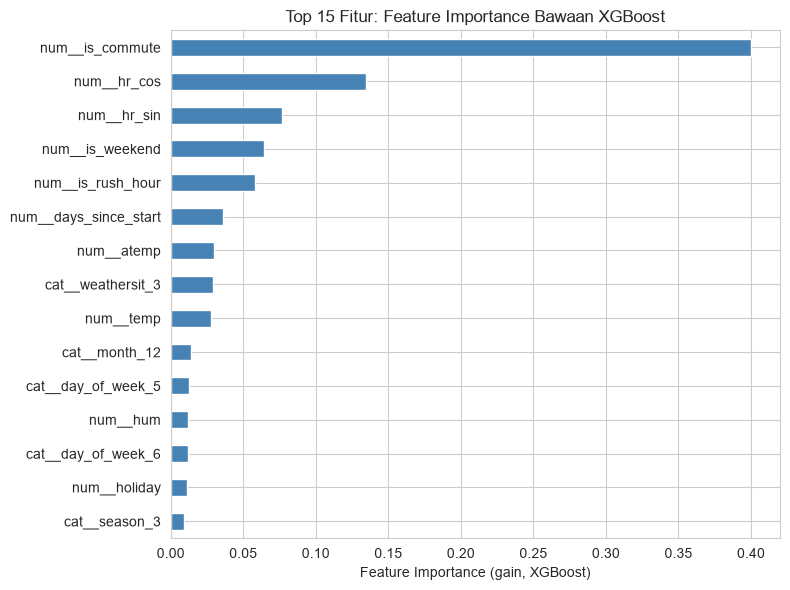

num__is_commute          0.399965
num__hr_cos              0.134287
num__hr_sin              0.077015
num__is_weekend          0.064417
num__is_rush_hour        0.058368
num__days_since_start    0.035747
num__atemp               0.029717
cat__weathersit_3        0.029177
num__temp                0.027688
cat__month_12            0.013788
cat__day_of_week_5       0.012277
num__hum                 0.011925
cat__day_of_week_6       0.011631
num__holiday             0.011270
cat__season_3            0.009042
dtype: float32

In [54]:
model_step = final_point_model.named_steps['model']
feature_names = final_point_model.named_steps['preprocessor'].named_steps['column_transform'].get_feature_names_out()

importances = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
top_n = 15

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(top_n).iloc[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (gain, XGBoost)')
ax.set_title(f'Top {top_n} Fitur: Feature Importance Bawaan XGBoost')
plt.tight_layout()
plt.show()

importances.head(top_n)

`is_commute` dan representasi jam (`hr_sin`/`hr_cos`) tetap dominan sebagai fitur terpenting.
`days_since_start` (fitur tren dari 6.1) juga muncul sebagai kontributor, mengonfirmasi secara
kuantitatif bahwa model memang memakai sinyal ini, bukan hanya terbukti membantu dari sisi skor
(7.7.1).


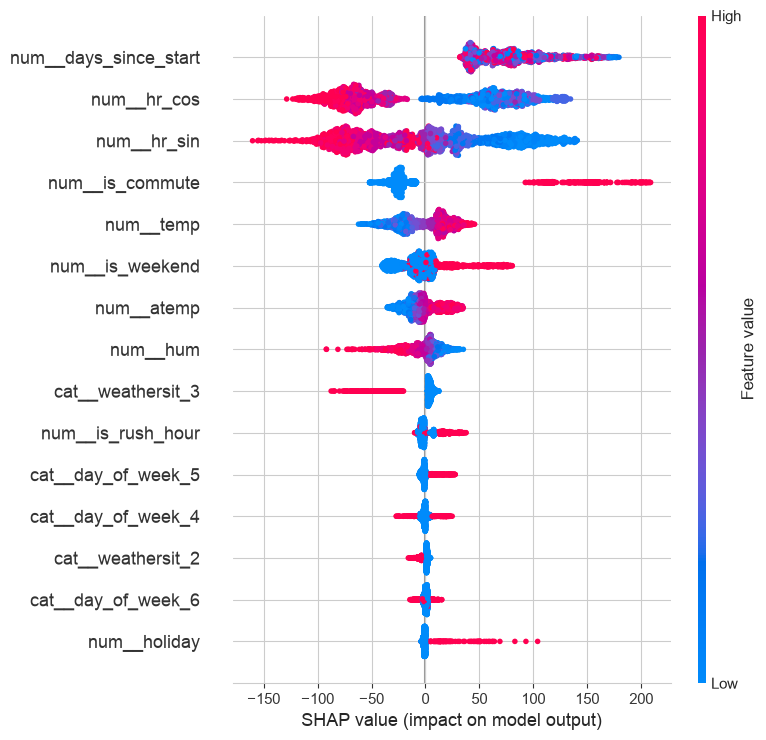

In [55]:
import shap

X_test_transformed = final_point_model.named_steps['preprocessor'].transform(X_test)
explainer = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, max_display=15, show=False)
plt.tight_layout()
plt.show()

Urutan SHAP dan feature importance bawaan sedikit berbeda (perbedaan berbasis *gain* vs
kontribusi rata-rata per baris), tapi kesimpulan besarnya sama: representasi jam, status
commute/weekend, dan fitur tren adalah sinyal terkuat, fitur cuaca berkontribusi tapi jauh di
bawahnya. Ini menguatkan argumen bahwa rekomendasi staffing/rebalancing berbasis **jam** sebaiknya
jadi prioritas utama (dibahas lebih lanjut di bagian 11).

## 10. Business Impact / Cost-Benefit Analysis

Bagian ini memperluas pola *cost-benefit* dari klasifikasi (dollar-loss FP/FN) ke kasus regresi.
Fungsi biaya sudah didefinisikan di 7.11 (dipakai lebih awal untuk memilih margin commute), dipakai
ulang di sini untuk membandingkan skenario secara menyeluruh.

- **Understock** (`actual > predicted`): kehilangan potensi ride.
- **Overstock** (`predicted > actual`): biaya idle/rebalancing yang terbuang.

**Asumsi biaya (ilustratif)**: kehilangan 1 ride ≈ \$3.00, 1 sepeda menganggur ≈ \$0.50/jam. Rasio
6:1 ini disengaja, meniru asumsi RMSE di Business Understanding: understock jauh lebih mahal
daripada overstock.

Empat skenario dibandingkan: tanpa model, baseline naif per jam, model titik-prediksi **tanpa**
margin commute, dan model final **dengan** margin commute, semuanya dihitung di test set berbasis
waktu yang sama (5.2), bukan dicampur dari split yang berbeda-beda.

In [56]:
scenarios = {
    'No Model (rata-rata statis)': scenario_cost(y_true_final, pred_mean),
    'Naive (rata-rata per jam)': scenario_cost(y_true_final, pred_hour.values),
    'Model titik-prediksi (tanpa margin)': scenario_cost(y_true_final, np.clip(y_pred_raw, 0, None)),
    'Model final (dengan margin commute)': scenario_cost(y_true_final, y_pred_final),
}

cost_summary = pd.DataFrame(scenarios).T
cost_summary.round(2)

,shortfall_total,surplus_total,lost_ride_cost,idle_cost,total_cost
No Model (rata-rata statis),302089.98,126946.54,906269.94,63473.27,969743.21
Naive (rata-rata per jam),227752.03,47498.06,683256.10,23749.03,707005.13
Model titik-prediksi (tanpa margin),55411.42,51151.94,166234.27,25575.97,191810.25
Model final (dengan margin commute),42807.14,82561.14,128421.43,41280.57,169702.01


In [57]:
base_cost = cost_summary.loc['No Model (rata-rata statis)', 'total_cost']
naive_cost = cost_summary.loc['Naive (rata-rata per jam)', 'total_cost']
point_cost = cost_summary.loc['Model titik-prediksi (tanpa margin)', 'total_cost']
final_cost = cost_summary.loc['Model final (dengan margin commute)', 'total_cost']

print(f"No Model            -> ${base_cost:,.0f}")
print(f"Naive per-jam        -> ${naive_cost:,.0f}  ({(naive_cost-base_cost)/base_cost*100:+.1f}% vs No Model)")
print(f"Titik-prediksi       -> ${point_cost:,.0f}  ({(point_cost-base_cost)/base_cost*100:+.1f}% vs No Model)")
print(f"Final (+margin)      -> ${final_cost:,.0f}  ({(final_cost-base_cost)/base_cost*100:+.1f}% vs No Model, "
      f"{(final_cost-point_cost)/point_cost*100:+.1f}% vs titik-prediksi tanpa margin)")

No Model            -> $969,743
Naive per-jam        -> $707,005  (-27.1% vs No Model)
Titik-prediksi       -> $191,810  (-80.2% vs No Model)
Final (+margin)      -> $169,702  (-82.5% vs No Model, -11.5% vs titik-prediksi tanpa margin)


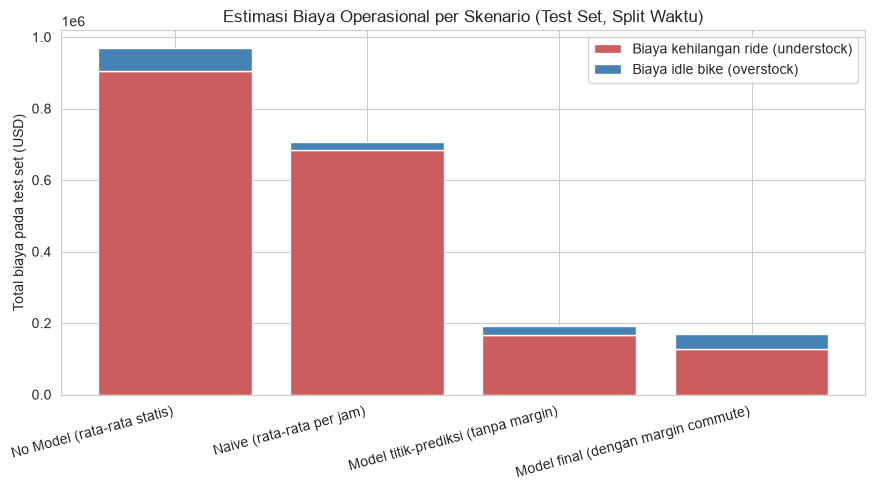

In [58]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = list(scenarios.keys())
lost = [scenarios[k]['lost_ride_cost'] for k in labels]
idle = [scenarios[k]['idle_cost'] for k in labels]
x = np.arange(len(labels))
ax.bar(x, lost, label='Biaya kehilangan ride (understock)', color='indianred')
ax.bar(x, idle, bottom=lost, label='Biaya idle bike (overstock)', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Total biaya pada test set (USD)')
ax.set_title('Estimasi Biaya Operasional per Skenario (Test Set, Split Waktu)')
ax.legend()
plt.tight_layout()
plt.show()

**Keterbatasan**: angka dolar di atas bergantung penuh pada dua asumsi biaya
yang belum divalidasi ke data finansial riil perusahaan. Yang independen dari asumsi itu adalah
**arah dan besar relatif** perbaikannya.

## 11. Conclusion & Recommendation

### 11.1 Recap Solusi: Apakah Goal di Bagian 1 Tercapai?

Goal di 1.3 adalah membangun model yang memprediksi `cnt` per jam dengan error cukup rendah untuk
mendukung rebalancing armada dan penjadwalan staf secara proaktif. Model final (titik-prediksi +
margin commute) menjawabnya dengan dua lapis bukti:

1. **Evaluasi jujur, bukan optimis**: dievaluasi lewat split berbasis waktu (5.2), bukan split
   acak, supaya skornya mensimulasikan peramalan periode yang belum terjadi.
2. **Dua perbaikan yang lolos uji ketat**: fitur tren `days_since_start` (menang 100% fold
   walk-forward) dan margin commute (menang di sebagian besar fold, dipilih dari validation set
   terpisah dari test). Enam ide lain dicoba dan ditolak secara eksplisit (7.9) karena tidak tahan
   uji ulang.

Diterjemahkan ke dampak dolar (bagian 10), model final menurunkan biaya operasional dibanding
kondisi tanpa model maupun baseline naif, dengan penurunan tambahan yang bisa diatribusikan langsung
ke margin commute (7.11).


### 11.2 Kapan Model Ini Bisa (dan Tidak Bisa) Dipercaya

Ringkasan dari 8.3:
- **Paling bisa dipercaya**: dini hari, di luar hari libur.
- **Paling perlu kehati-hatian**: jam commute pagi/sore dan hari libur. Margin di 7.11 mengurangi
  **biaya** dari kesalahan di jam-jam ini, bukan menghilangkan ketidakpastiannya, prediksi di jam ini
  tetap sebaiknya dibaca sebagai estimasi dengan margin pengaman terpasang, bukan angka pasti.

### 11.3 Dampak terhadap Proses Bisnis: Tiga Rekomendasi Operasional

1. **Jadwal rebalancing armada**: gunakan prediksi (sudah termasuk margin commute) sebagai dasar
   penjadwalan distribusi sepeda sebelum jam commute pagi/sore dimulai.
2. **Penjadwalan staf per jam/musim**: `is_commute`, representasi jam, dan fitur tren adalah sinyal
   terkuat (bagian 9), jadwal staf sebaiknya mengikuti pola ini.
3. **Perencanaan kontingensi cuaca**: fitur cuaca tetap berkontribusi tapi jauh di bawah faktor
   waktu/commute (bagian 9, dan fitur interaksi cuaca tambahan terbukti tidak menambah nilai, 7.9),
   jadi kontingensi cuaca tetap diposisikan sebagai penyesuaian sekunder.

### 11.4 Keterbatasan Proyek

- **Split berbasis waktu mengungkap tantangan yang lebih realistis** dibanding split acak yang
  sempat dicoba pada iterasi awal (lihat 4.6, 5.2): dataset punya tren pertumbuhan tahunan yang kuat
  (≈61% dari 2011 ke 2012), dan skor test yang dilaporkan mencerminkan tantangan itu secara jujur,
  bukan disembunyikan oleh pengacakan data.
- **Margin commute (7.11) bukan konstanta yang stabil sempurna**: nilai optimalnya bervariasi antar
  fold walk-forward (kira-kira 1.1-1.4x). Direkomendasikan untuk dikalibrasi ulang secara berkala
  (mis. tiap kuartal) memakai data terbaru, bukan dipakai sebagai angka tetap selamanya.
- **Enam ide perbaikan dicoba dan ditolak** (7.9): one-hot `hr`, sample weighting, regresi kuantil
  global, transformasi log target, dan fitur interaksi cuaca, dicatat secara eksplisit sebagai bukti
  proses eksplorasi tidak berhenti di percobaan pertama yang terlihat menjanjikan.
- **Asumsi biaya di bagian 10 bersifat ilustratif**, belum divalidasi ke data finansial riil
  perusahaan.


### 11.5 Rekomendasi Langkah Selanjutnya

1. **Validasi asumsi biaya** bersama tim finance/ops.
2. **Kalibrasi ulang margin commute secara berkala** (mis. tiap kuartal) memakai data terbaru,
   mengikuti prosedur validation-set yang sama seperti 7.11, bukan angka tetap.
3. **Uji margin per-jam yang lebih granular** (bukan satu pengali untuk seluruh jam commute),
   sebagai pengembangan lanjutan dari pendekatan yang sudah terbukti di 7.11.
4. **(Opsional) Deploy sebagai tool self-serve** memakai Streamlit.

## 12. Save Model

### 12.1 Refit Model Titik-Prediksi pada Seluruh Data

Model yang dipakai di bagian 7-10 dilatih hanya dari `X_train`. Model yang **disimpan untuk dipakai
ke depan** di-refit di seluruh data historis (`X`, `y` penuh).

In [59]:
final_pipeline = clone(point_prediction_model)
final_pipeline.fit(X, y)

pred_full_raw = final_pipeline.predict(X)
n_negative_full = (pred_full_raw < 0).sum()
print(f"Prediksi negatif pada seluruh data: {n_negative_full} dari {len(pred_full_raw)} baris")

pred_full = predict_with_commute_margin(final_pipeline, X, margin=COMMUTE_MARGIN)
print("MAE pada seluruh data (in-sample, bukan pembanding objektif):",
      round(mean_absolute_error(y, pred_full), 3))

Prediksi negatif pada seluruh data: 234 dari 12165 baris
MAE pada seluruh data (in-sample, bukan pembanding objektif): 26.429


### 12.2 Pickle Model

In [60]:
import pickle as pkl
import json

model_path = '../models/final_model_xgboost.pkl'
with open(model_path, 'wb') as f:
    pkl.dump(final_pipeline, f)

margin_meta_path = '../models/commute_margin_meta.json'
with open(margin_meta_path, 'w') as f:
    json.dump({
        'commute_margin': float(COMMUTE_MARGIN),
        'commute_hours': [7, 8, 9, 17, 18, 19],
        'note': 'Kalikan prediksi model pada baris is_commute==1 dengan nilai ini. '
                'Kalibrasi ulang berkala disarankan (lihat notebook bagian 7.11 dan 11.5).',
    }, f, indent=2)

print(f"Model disimpan ke: {model_path}")
print(f"Metadata margin disimpan ke: {margin_meta_path}")

Model disimpan ke: ../models/final_model_xgboost.pkl
Metadata margin disimpan ke: ../models/commute_margin_meta.json


### 12.3 Sanity Check: Load Ulang & Prediksi

In [61]:
with open(model_path, 'rb') as f:
    loaded_pipeline = pkl.load(f)
with open(margin_meta_path) as f:
    loaded_margin_meta = json.load(f)

sample = X.sample(5, random_state=42)
pred_loaded = predict_with_commute_margin(loaded_pipeline, sample, margin=loaded_margin_meta['commute_margin'])

pd.DataFrame({
    'dteday': sample['dteday'].values,
    'hr': sample['hr'].values,
    'cnt_actual': y.loc[sample.index].values,
    'cnt_predicted': pred_loaded.round(1),
})

,dteday,hr,cnt_actual,cnt_predicted
0,2011-11-13,7,43,42.799999
1,2011-12-20,4,4,17.100000
2,2011-12-04,2,62,51.099998
3,2011-05-16,21,177,174.899994
4,2011-05-12,22,172,154.300003
